In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.deterministic import DeterministicProcess, CalendarFourier
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.signal import periodogram
from sklearn.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_pacf
from xgboost import XGBRegressor

In [51]:
df = pd.read_csv (
    "teste/dados_sabesp_cantareira_historico.csv", sep=';', parse_dates=['Data'], dayfirst=True
)

In [52]:
df.head()

,Data,Chuva (mm),Volume Útil Armazenado (%),Volume Útil Armazenado (hm³),Volume Total Armazenado (hm³),Vazão Captada (m³/s),Vazão Produzida (m³/s),Vazão Jusante (m³/s),Vazão Natural (m³/s),Vazão Afluente (m³/s),Variação do Volume Útil (%),Chuva Acumulada no Mês (mm),Chuva Média Historica (mm),Vazão Jusante no mês (m³/s),Vazão Jusante Média Histórica (m³/s),Vazão Natural no Mês (m³/s),Vazão Natural Media Historica (m³/s),Vazão Produzida no Mês (m³/s),Vazão Retirada no Mês (m³/s)
0,2000-01-01,"30,9","47,11254","365,50555","1072,05098","29,0",NaN,"10,16","70,885","70,885","0,32635","30,9","261,51618","10,16","22,55533","70,885",NaN,NaN,"29,0"
1,2000-01-02,"29,1","47,77519","370,64646","1077,1919","28,8",NaN,"10,18","94,864","94,864","0,66265","60,0","261,51618","10,17","22,55533","82,875",NaN,NaN,"28,9"
2,2000-01-03,"35,175","48,59438","377,00187","1083,5473","33,3",NaN,"7,29","108,208","108,208","0,81919","95,175","261,51618","9,21","22,55533","91,319",NaN,NaN,"30,36667"
3,2000-01-04,"18,725","49,9968","387,88206","1094,42749","32,4",NaN,"6,34","162,936","162,936","1,40242","113,9","261,51618","8,4925","22,55533","109,223",NaN,NaN,"30,875"
4,2000-01-05,"25,9","51,94578","403,00251","1109,54794","32,9",NaN,"6,33","211,604","211,604","1,94898","139,8","261,51618","8,06","22,55533","129,699",NaN,NaN,"31,28"


In [53]:
dfv = df[['Data', 'Volume Útil Armazenado (%)']].copy()
dfv = dfv.rename(columns= {'Volume Útil Armazenado (%)':'Volume_util'})
dfv['Data'] = pd.to_datetime(dfv['Data'])
dfv = dfv.set_index('Data')
dfv.head()

,Volume_util
Data,
2000-01-01,"47,11254"
2000-01-02,"47,77519"
2000-01-03,"48,59438"
2000-01-04,"49,9968"
2000-01-05,"51,94578"


In [54]:
dfv.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9412 entries, 2000-01-01 to 2025-10-07
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Volume_util  9412 non-null   object
dtypes: object(1)
memory usage: 147.1+ KB


In [55]:
dfv['Volume_util'] = dfv['Volume_util'].str.strip()
dfv['Volume_util'] = dfv['Volume_util'].str.replace(',','.', regex=False)
dfv['Volume_util'] = pd.to_numeric(dfv['Volume_util'])

In [56]:
dfv.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9412 entries, 2000-01-01 to 2025-10-07
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Volume_util  9412 non-null   float64
dtypes: float64(1)
memory usage: 147.1 KB


In [57]:
dfv['Time'] = np.arange(len(dfv.index))
dfv.head()

,Volume_util,Time
Data,,
2000-01-01,47.11254,0
2000-01-02,47.77519,1
2000-01-03,48.59438,2
2000-01-04,49.99680,3
2000-01-05,51.94578,4


### Tendência da série temporal do volume útil do sistema cantareira

#### Tendência com a regressão linear

In [58]:
X = dfv.loc[:, ['Time']]
y = dfv.loc[:, ['Volume_util']]

model = LinearRegression()
model.fit(X,y)

y_pred = pd.Series(model.predict(X).flatten(), index=X.index)
dfv['y_pred'] = y_pred

Text(0, 0.5, 'Volume_util')

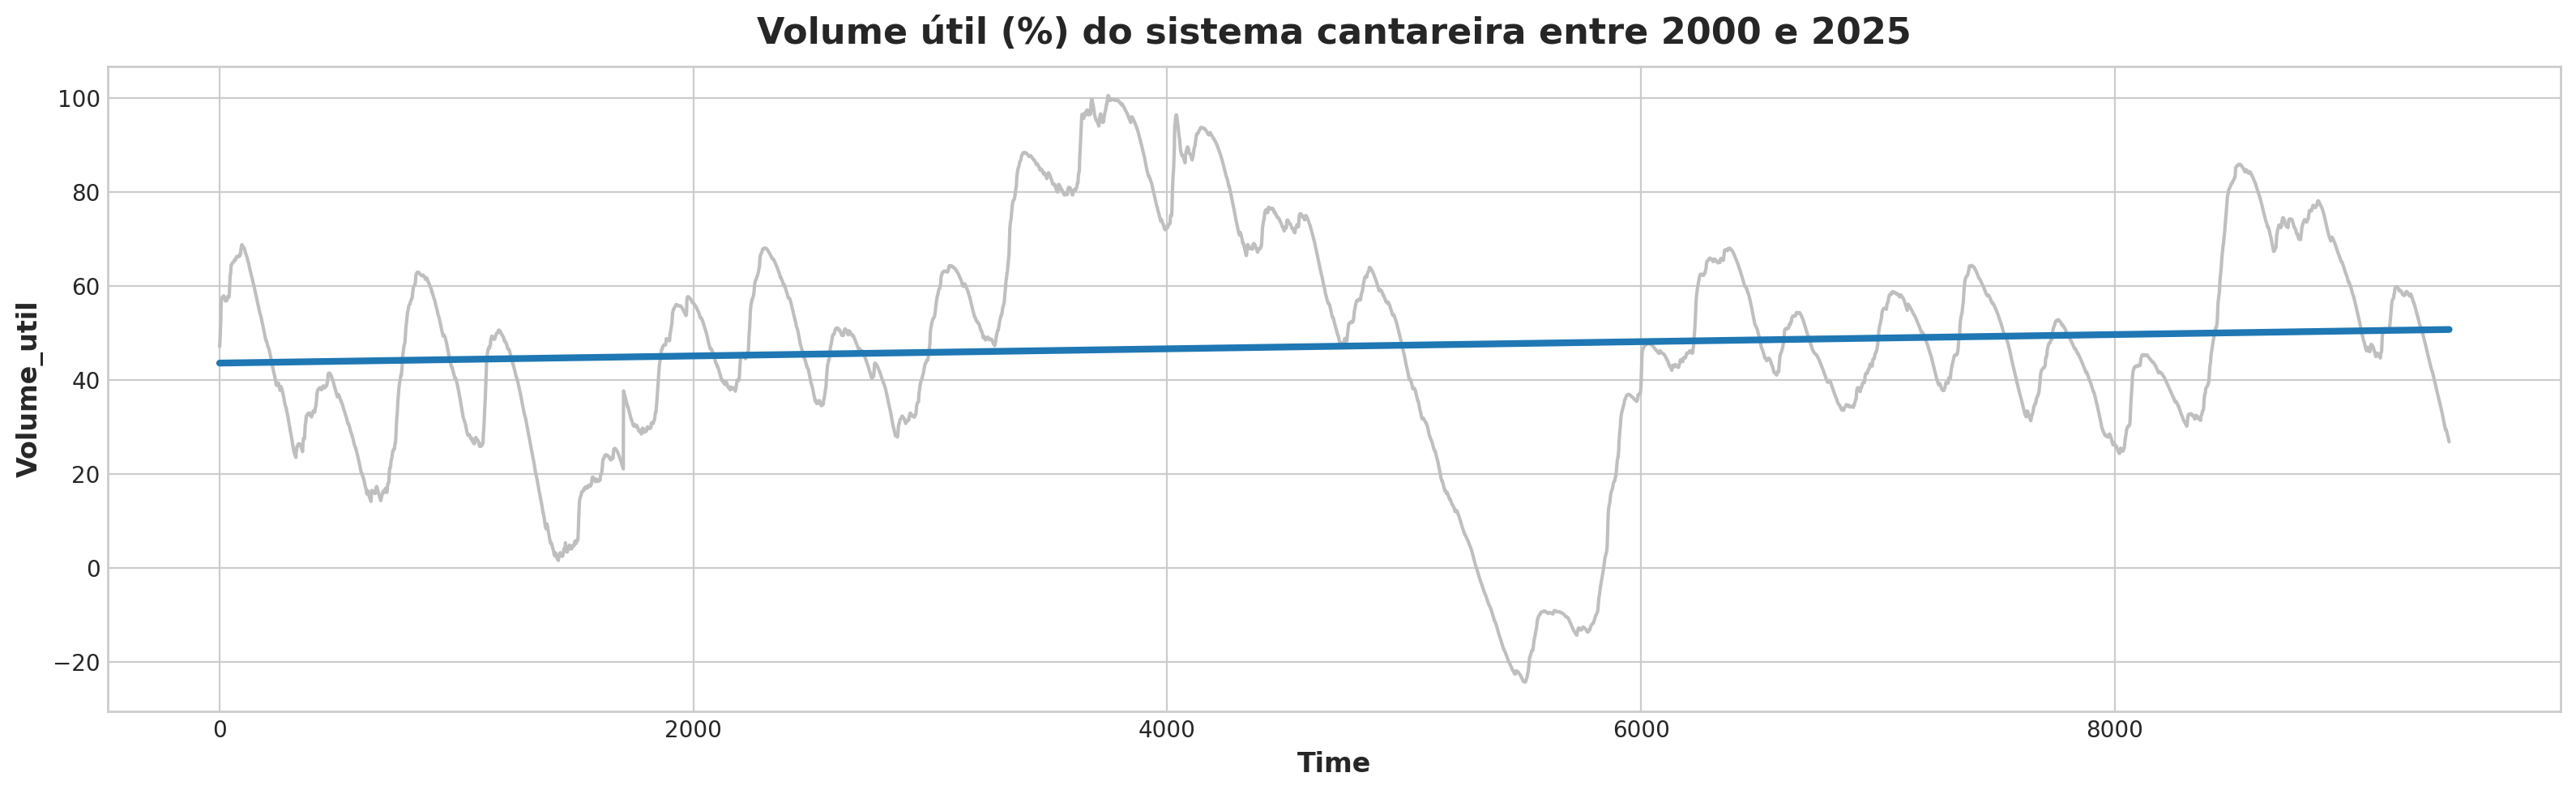

In [59]:
plt.style.use("seaborn-v0_8-whitegrid")

plt.rc(

    "figure",
    autolayout = True, 
    figsize = (11,4),
    titlesize = 18,
    titleweight = 'bold',

)

plt.rc(
    "axes",
    labelweight = 'bold',
    labelsize = "large",
    titleweight = "bold",
    titlesize = 16,
    titlepad = 10
    )

fig, ax = plt.subplots(figsize=(16,5))

ax.plot(dfv['Time'], dfv['Volume_util'], data=dfv, color= '0.75')
ax.plot (dfv['Time'], dfv['y_pred'], color='tab:blue', linewidth=3, label='Regressão Linear', zorder=3)

ax.set_title('Volume útil (%) do sistema cantareira entre 2000 e 2025')
ax.set_xlabel('Time')
ax.set_ylabel('Volume_util')

#### Visualizando a tendência por médias móveis

<Axes: title={'center': 'Volume útil do sistema cantareira em médias móveis'}, xlabel='Data'>

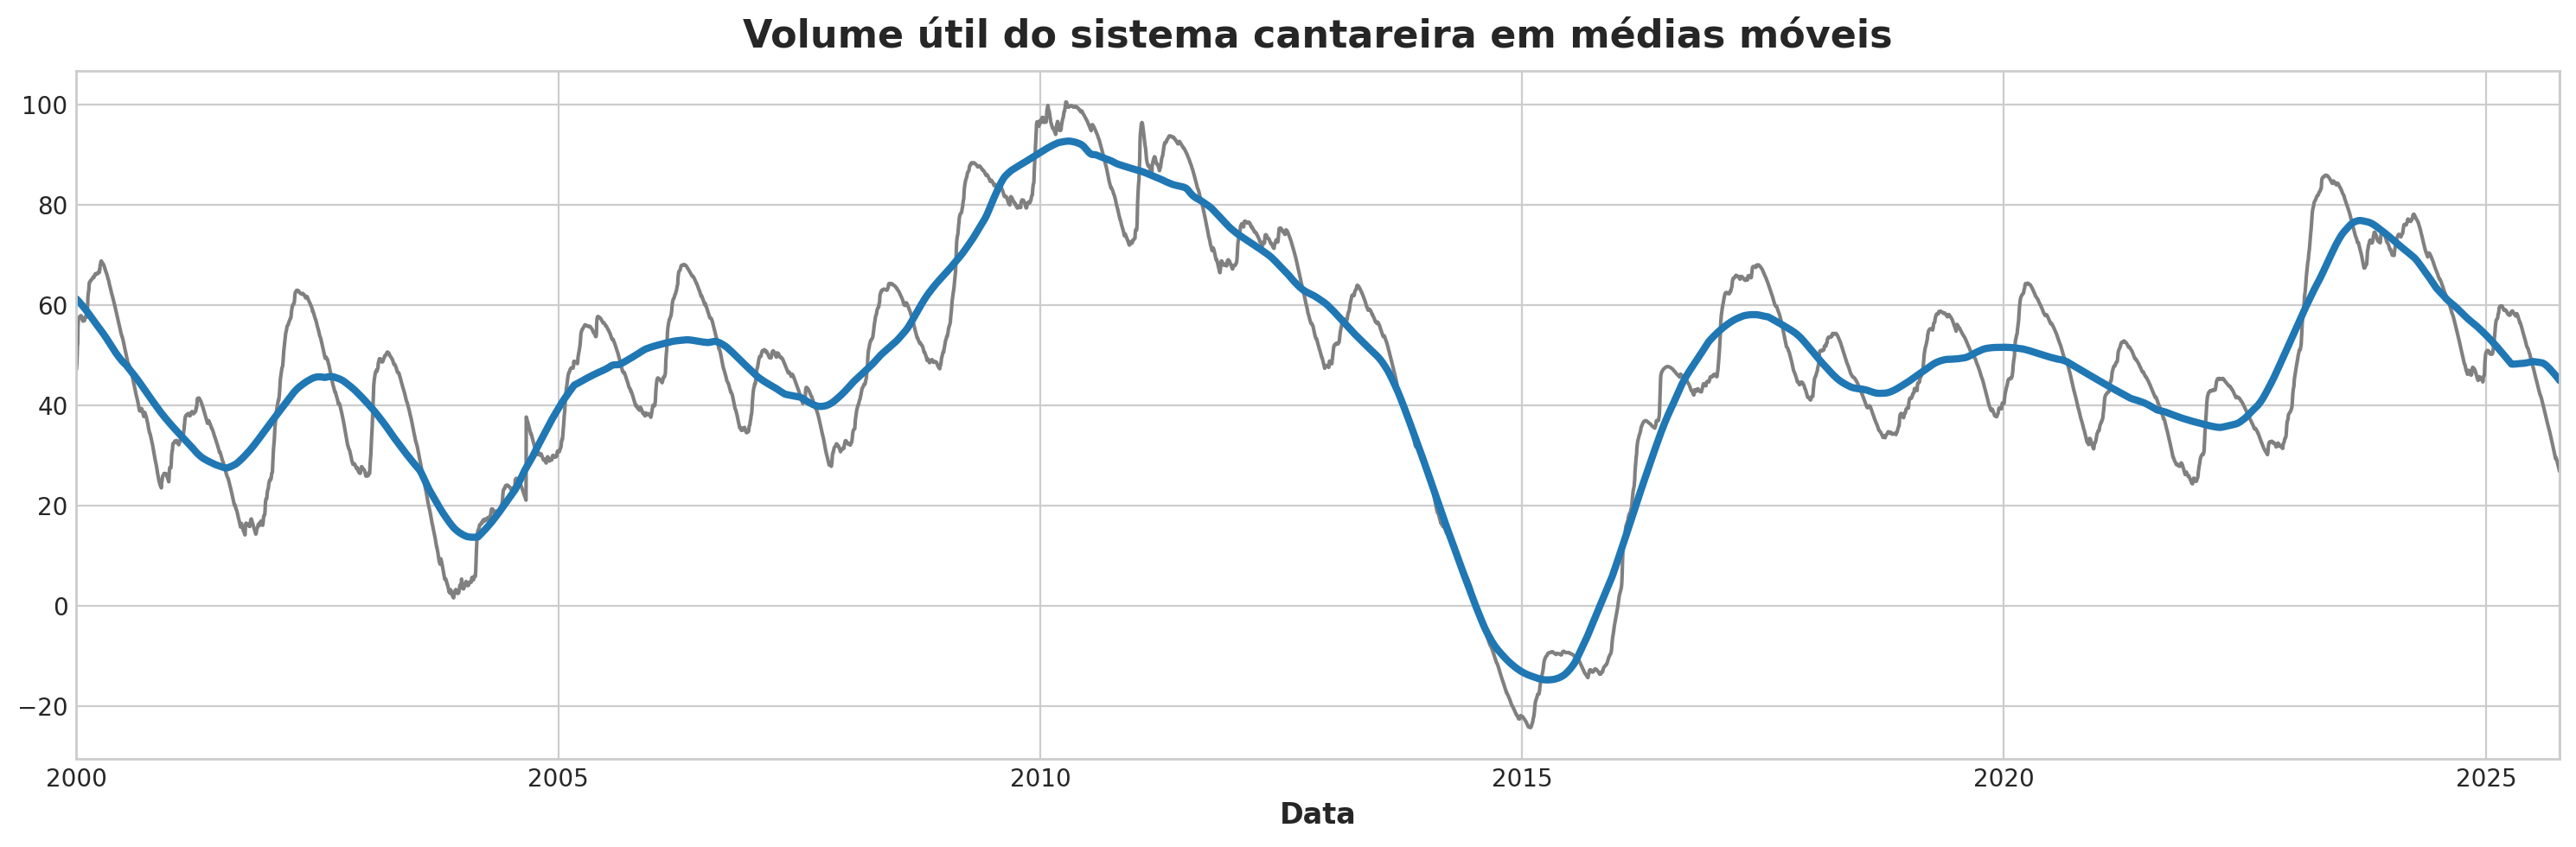

In [60]:
moving_average = dfv['Volume_util'].rolling(
    window = 365, 
    center = True, 
    min_periods = 182, 

).mean()

ax = dfv['Volume_util'].plot (style="-", color="0.5", figsize=(15,5))
moving_average.plot(
    ax=ax, linewidth=3, title = "Volume útil do sistema cantareira em médias móveis", legend=False
)

In [ ]:
#criando as features para previsão da tendência 

# dp = DeterministicProcess(
#     index=dfv.index,
#     constant=True,
#     order=3,
#     drop=True,
# )

# x = dp.in_sample()

# x.head()

,const,trend,trend_squared,trend_cubed
Data,,,,
2000-01-01,1.0,1.0,1.0,1.0
2000-01-02,1.0,2.0,4.0,8.0
2000-01-03,1.0,3.0,9.0,27.0
2000-01-04,1.0,4.0,16.0,64.0
2000-01-05,1.0,5.0,25.0,125.0


In [ ]:
# y=dfv['Volume_util']
# model = LinearRegression()
# model.fit(x,y)

# y_pred = pd.Series (model.predict(x), index=x.index)

/home/jefferson_correia/tcc/venv/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


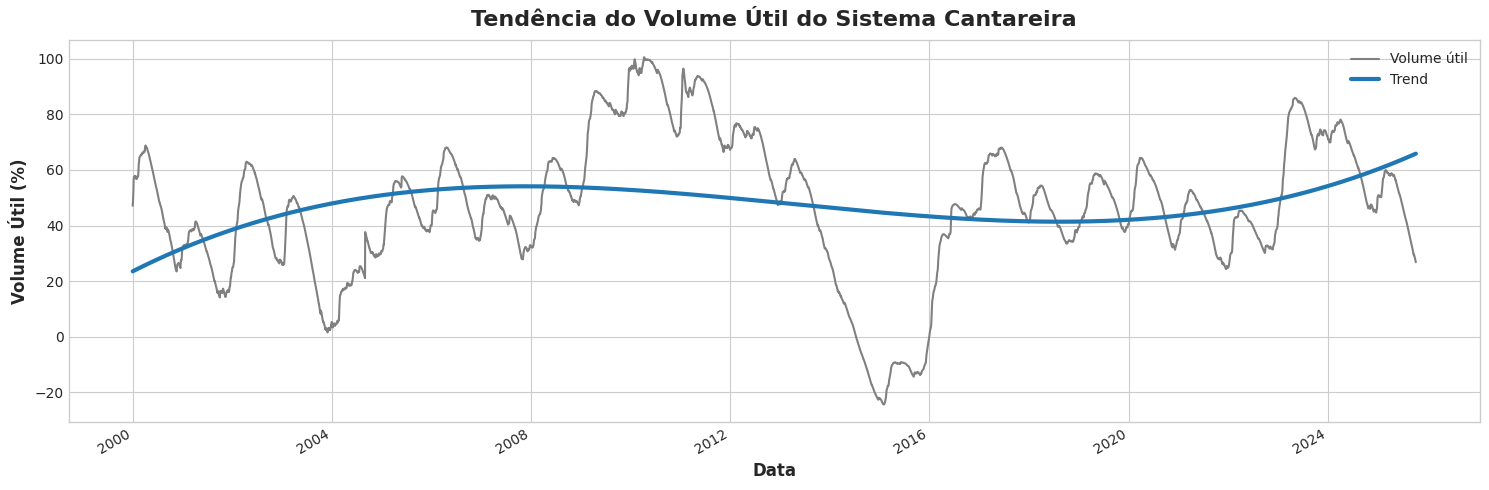

In [ ]:
# fig, ax = plt.subplots(figsize=(15, 5))
# ax.plot(dfv.index, dfv['Volume_util'], linestyle = "-", color = "0.5", label = "Volume útil")
# _ = y_pred.plot(ax=ax, linewidth=3, label="Trend")

# ax.set_title("Tendência do Volume Útil do Sistema Cantareira")
# ax.set_xlabel("Data")
# ax.set_ylabel("Volume Útil (%)")
# ax.legend()

#### Tendência + Sazonalidade usando termos de Fourier 

In [61]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rc("figure", autolayout=True, figsize=(11, 5))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)

plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
    legend=False,
)

%config InlineBackend.figure_format = 'retina'

def seasonal_plot (X, y, period, freq, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    palette = sns.color_palette("husl", n_colors = X[period].nunique(),)
    ax = sns.lineplot(
        x=freq,
        y=y,
        hue=period,
        data=X,
        ci=False,
        ax=ax,
        palette=palette,
        legend=False,
    )
    ax.set_title(f"Seasonal Plot ({period}/{freq})")
    for line, name in zip(ax.lines, X[period].unique()):
        y_ = line.get_ydata()[-1]
        ax.annotate(
            name,
            xy=(1, y_),
            xytext=(6, 0),
            color=line.get_color(),
            xycoords=ax.get_yaxis_transform(),
            textcoords="offset points",
            size=14,
            va="center",
        )

    return ax 

def plot_periodogram(ts, detrend='linear', ax=None):
    from scipy.signal import periodogram
    fs=pd.Timedelta("365D") / pd.Timedelta("1D")
    frequencies, spectrum = periodogram(
        ts,
        fs=fs,
        detrend=detrend,
        window="boxcar",
        scaling='spectrum',
    )
    if ax is None:
        _, ax = plt.subplots()
    ax.step(frequencies, spectrum, color="purple")
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 4, 6, 12, 26, 52, 104])
    ax.set_xticklabels(
        [
            
            "Annual (1)",
            "Semiannual (2)",
            "Quarterly (4)",
            "Bimonthly (6)",
            "Monthly (12)",
            "Biweekly (26)",
            "Weekly (52)",
            "Semiweekly (104)",
        ],
        rotation=30,
    )

    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_ylabel("Variance")
    ax.set_title("Periodogram")
    return ax

/tmp/ipykernel_5982/3960733576.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  ax = sns.lineplot(


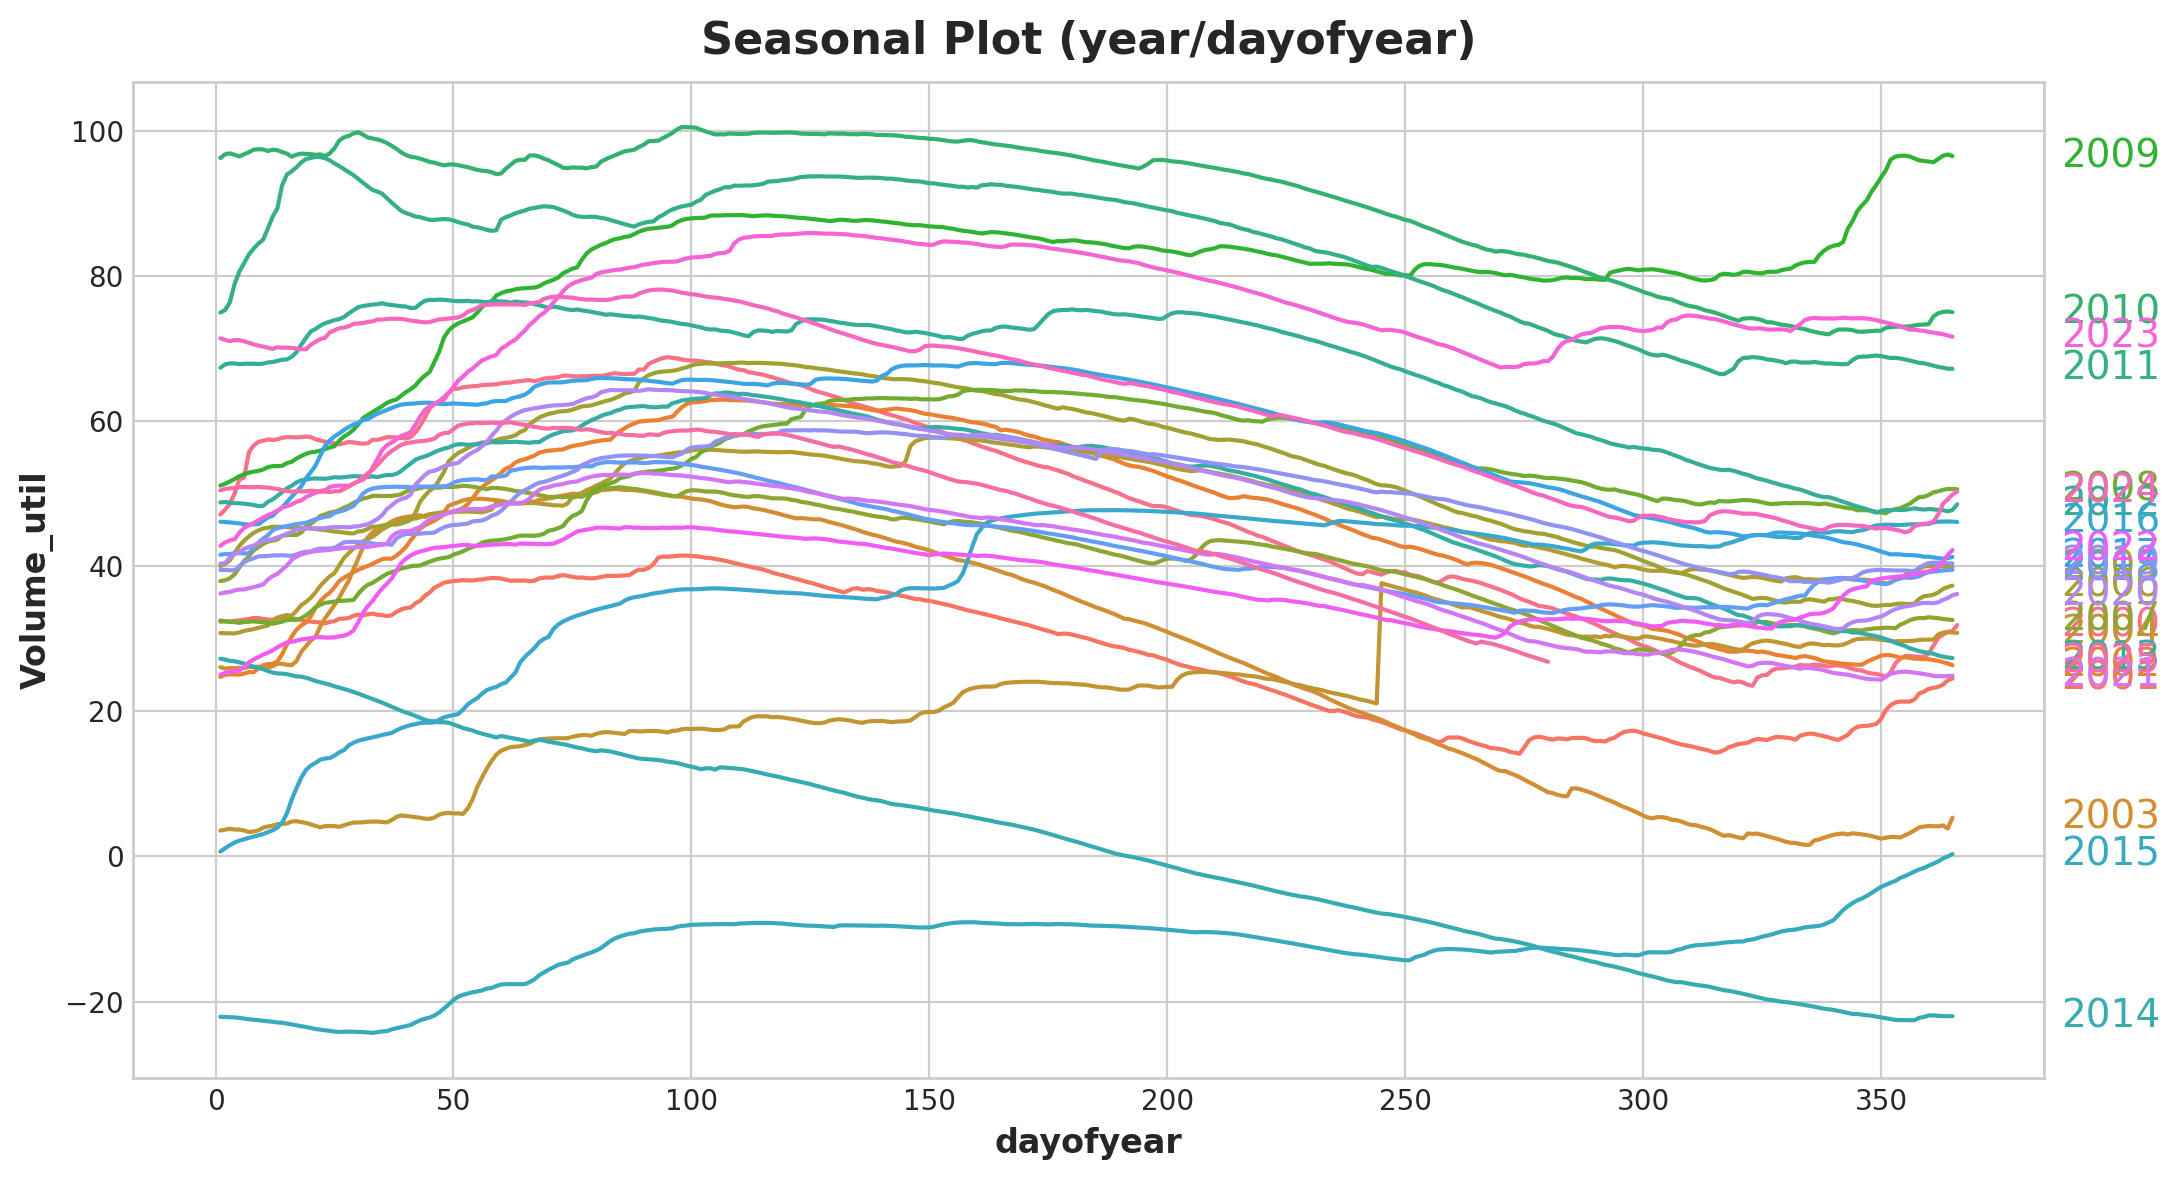

In [62]:
x1 = dfv.copy()

x1['dayofyear'] = x1.index.dayofyear
x1['year'] = x1.index.year
fig, ax = plt.subplots(figsize=(11, 6))
seasonal_plot(x1, y="Volume_util", period="year", freq="dayofyear", ax=ax);

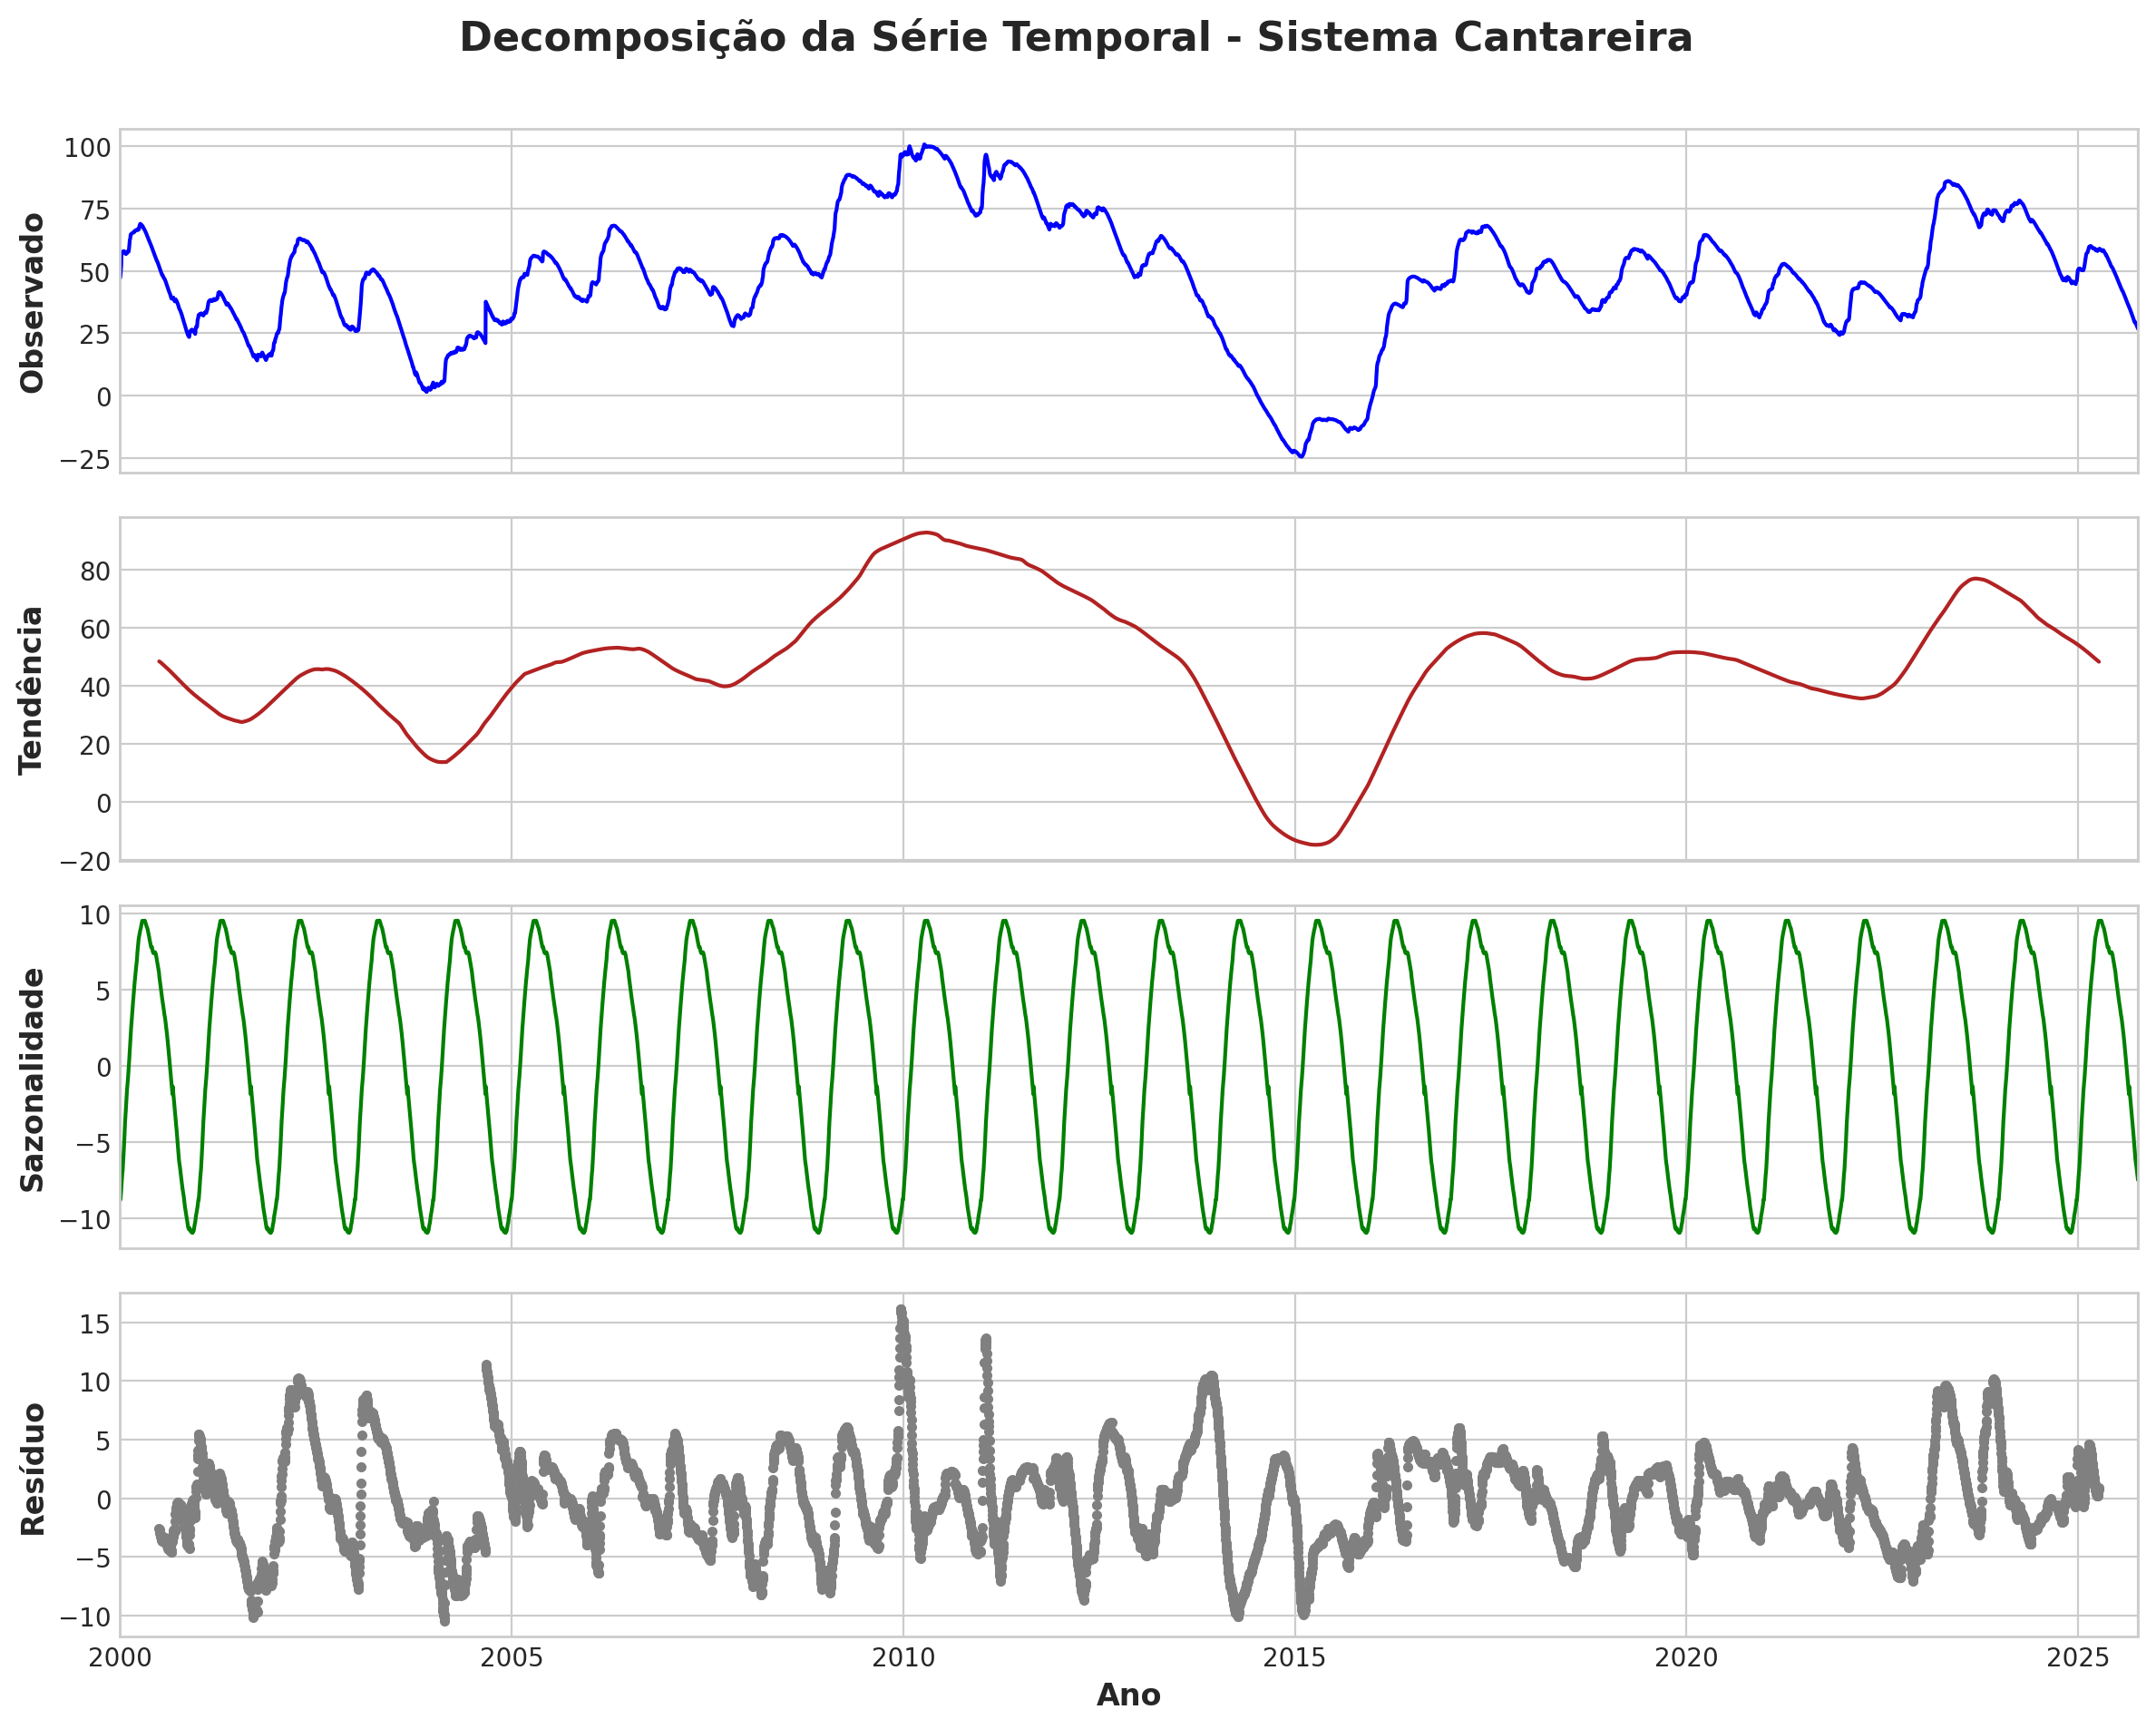

In [63]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposicao = seasonal_decompose(dfv['Volume_util'], model='additive', period=365)

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 10))


decomposicao.observed.plot(ax=axes[0], color='blue', legend=False)
axes[0].set_ylabel('Observado')


decomposicao.trend.plot(ax=axes[1], color='firebrick', legend=False)
axes[1].set_ylabel('Tendência')


decomposicao.seasonal.plot(ax=axes[2], color='green', legend=False)
axes[2].set_ylabel('Sazonalidade')


decomposicao.resid.plot(ax=axes[3], color='gray', legend=False, style='.')
axes[3].set_ylabel('Resíduo')


fig.suptitle('Decomposição da Série Temporal - Sistema Cantareira', fontsize=16)
plt.xlabel('Ano')
plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Ajusta o layout para o título principal não sobrepor os gráficos
plt.show()

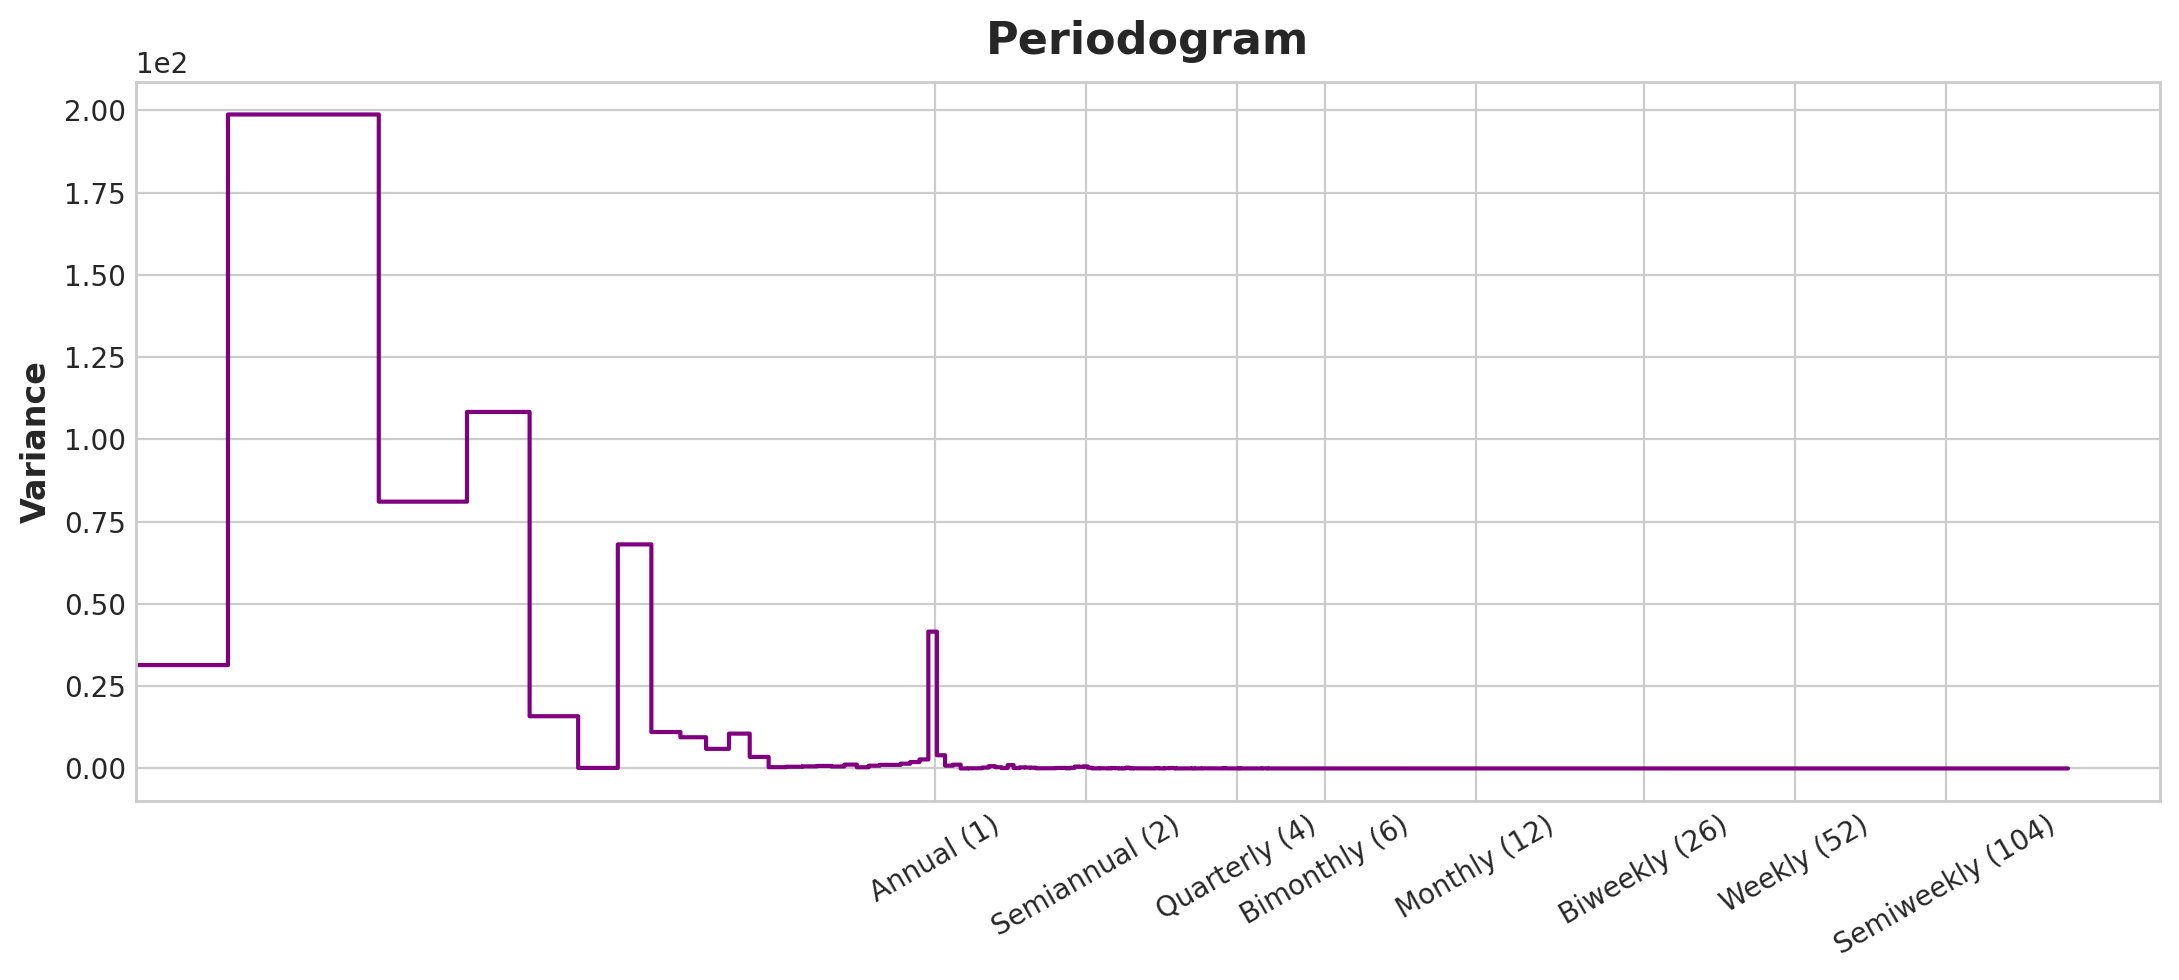

In [64]:
plot_periodogram(dfv.Volume_util);

In [65]:
dfv.head()
dfv.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9412 entries, 2000-01-01 to 2025-10-07
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Volume_util  9412 non-null   float64
 1   Time         9412 non-null   int64  
 2   y_pred       9412 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 294.1 KB


In [124]:
#prevendo tendência + sazonalidade juntas 
dfv = dfv.asfreq('D')
fourier = CalendarFourier(freq = "A", order = 4)

dp = DeterministicProcess(
    index=dfv.index,
    constant=True,               # dummy feature for bias (y-intercept)
    order=3,                     # trend (order 1 means linear)
    seasonal=True,               # weekly seasonality (indicators)
    additional_terms=[fourier],  # annual seasonality (fourier)
    drop=True,                   # drop terms to avoid collinearity
)

x1 = dp.in_sample()

/home/jefferson_correia/tcc/venv/lib/python3.12/site-packages/statsmodels/tsa/deterministic.py:569: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)


In [125]:
x1.head()

,const,trend,trend_squared,trend_cubed,"s(2,7)","s(3,7)","s(4,7)","s(5,7)","s(6,7)","s(7,7)","sin(1,freq=YE-DEC)","cos(1,freq=YE-DEC)","sin(2,freq=YE-DEC)","cos(2,freq=YE-DEC)","sin(3,freq=YE-DEC)","cos(3,freq=YE-DEC)","sin(4,freq=YE-DEC)","cos(4,freq=YE-DEC)"
Data,,,,,,,,,,,,,,,,,,
2000-01-01,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
2000-01-02,1.0,2.0,4.0,8.0,1.0,0.0,0.0,0.0,0.0,0.0,0.017166,0.999853,0.034328,0.999411,0.051479,0.998674,0.068615,0.997643
2000-01-03,1.0,3.0,9.0,27.0,0.0,1.0,0.0,0.0,0.0,0.0,0.034328,0.999411,0.068615,0.997643,0.102821,0.994700,0.136906,0.990584
2000-01-04,1.0,4.0,16.0,64.0,0.0,0.0,1.0,0.0,0.0,0.0,0.051479,0.998674,0.102821,0.994700,0.153891,0.988088,0.204552,0.978856
2000-01-05,1.0,5.0,25.0,125.0,0.0,0.0,0.0,1.0,0.0,0.0,0.068615,0.997643,0.136906,0.990584,0.204552,0.978856,0.271234,0.962513


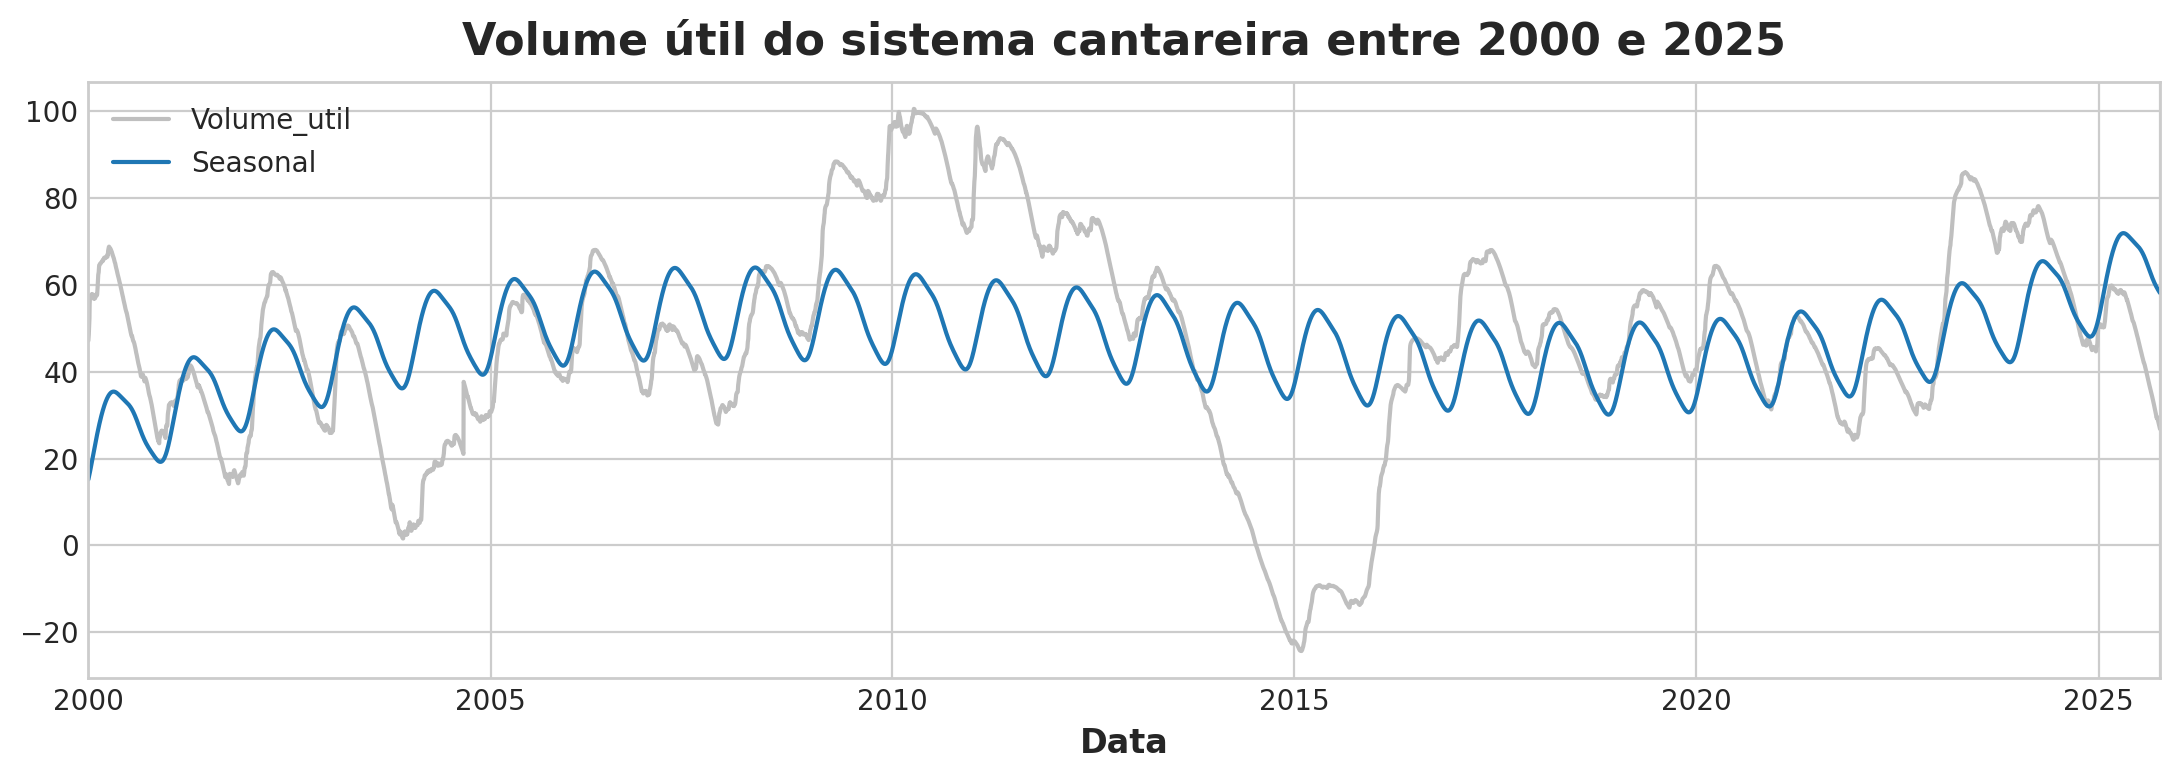

In [126]:
y1 = dfv["Volume_util"]

model1 = LinearRegression()
_ = model1.fit(x1, y1)

y_pred1 = pd.Series(model1.predict(x1), index=y1.index)
#X_fore = dp.out_of_sample(steps=1825)
#y_fore = pd.Series(model.predict(X_fore), index=X_fore.index)

ax = y1.plot(color='0.75', style='-', title="Volume útil do sistema cantareira entre 2000 e 2025")
ax = y_pred1.plot(ax=ax, label="Seasonal")
#ax = y_fore.plot(ax=ax, label="Seasonal Forecast", color='C3')
_ = ax.legend()

In [127]:
y_res = y1 - y_pred1

In [128]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rc("figure", autolayout=True, figsize=(11, 4))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style="-.",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
)
%config InlineBackend.figure_format = 'retina'


def lagplot(x, y=None, lag=1, standardize=False, ax=None, **kwargs):
    from matplotlib.offsetbox import AnchoredText
    x_ = x.shift(lag)
    if standardize:
        x_ = (x_ - x_.mean()) / x_.std()
    if y is not None:
        y_ = (y - y.mean()) / y.std() if standardize else y
    else:
        y_ = x
    corr = y_.corr(x_)
    if ax is None:
        fig, ax = plt.subplots()
    scatter_kws = dict(
        alpha=0.75,
        s=3,
    )
    line_kws = dict(color='C3', )
    ax = sns.regplot(x=x_,
                     y=y_,
                     scatter_kws=scatter_kws,
                     line_kws=line_kws,
                     lowess=True,
                     ax=ax,
                     **kwargs)
    at = AnchoredText(
        f"{corr:.2f}",
        prop=dict(size="large"),
        frameon=True,
        loc="upper left",
    )
    at.patch.set_boxstyle("square, pad=0.0")
    ax.add_artist(at)
    ax.set(title=f"Lag {lag}", xlabel=x_.name, ylabel=y_.name)
    return ax


def plot_lags(x, y=None, lags=6, nrows=1, lagplot_kwargs={}, **kwargs):
    import math
    kwargs.setdefault('nrows', nrows)
    kwargs.setdefault('ncols', math.ceil(lags / nrows))
    kwargs.setdefault('figsize', (kwargs['ncols'] * 2, nrows * 2 + 0.5))
    fig, axs = plt.subplots(sharex=True, sharey=True, squeeze=False, **kwargs)
    for ax, k in zip(fig.get_axes(), range(kwargs['nrows'] * kwargs['ncols'])):
        if k + 1 <= lags:
            ax = lagplot(x, y, lag=k + 1, ax=ax, **lagplot_kwargs)
            ax.set_title(f"Lag {k + 1}", fontdict=dict(fontsize=14))
            ax.set(xlabel="", ylabel="")
        else:
            ax.axis('off')
    plt.setp(axs[-1, :], xlabel=x.name)
    plt.setp(axs[:, 0], ylabel=y.name if y is not None else x.name)
    fig.tight_layout(w_pad=0.1, h_pad=0.1)
    return fig


In [129]:
# _ = plot_lags(dfv.Volume_util, lags=12, nrows=2)
# _ = plot_pacf(dfv.Volume_util, lags=12)

In [130]:
def make_lags(ts, lags):
    return pd.concat(
        {
            f'y_lag_{i}': ts.shift(i)
            for i in range(1, lags + 1)
        },
        axis=1)


x2 = make_lags(y_res, lags=3)
x2 = x2.fillna(0.0)

In [131]:
# Create target series and data splits
y2 = dfv.Volume_util.copy()
X_train, X_test, y_train_res, y_test_res = train_test_split(x2, y_res, test_size=1460, shuffle=False)


model2 = XGBRegressor(n_estimators = 50, learning_rate = 0.05, max_depth = 5 )  # `fit_intercept=True` since we didn't use DeterministicProcess
model2.fit(X_train, y_train_res)
y_pred_res = pd.Series(model2.predict(X_train), index=y_train_res.index)
y_fore_res = pd.Series(model2.predict(X_test), index=y_test_res.index)

In [132]:
X_train.head()

,y_lag_1,y_lag_2,y_lag_3
Data,,,
2000-01-01,0.000000,0.000000,0.000000
2000-01-02,31.946635,0.000000,0.000000
2000-01-03,32.382239,31.946635,0.000000
2000-01-04,32.969129,32.382239,31.946635
2000-01-05,34.135333,32.969129,32.382239


In [134]:
y_pred_final = y_pred1.loc[y_pred_res.index] + y_pred_res
y_fore_final = y_pred1.loc[y_fore_res.index] + y_fore_res

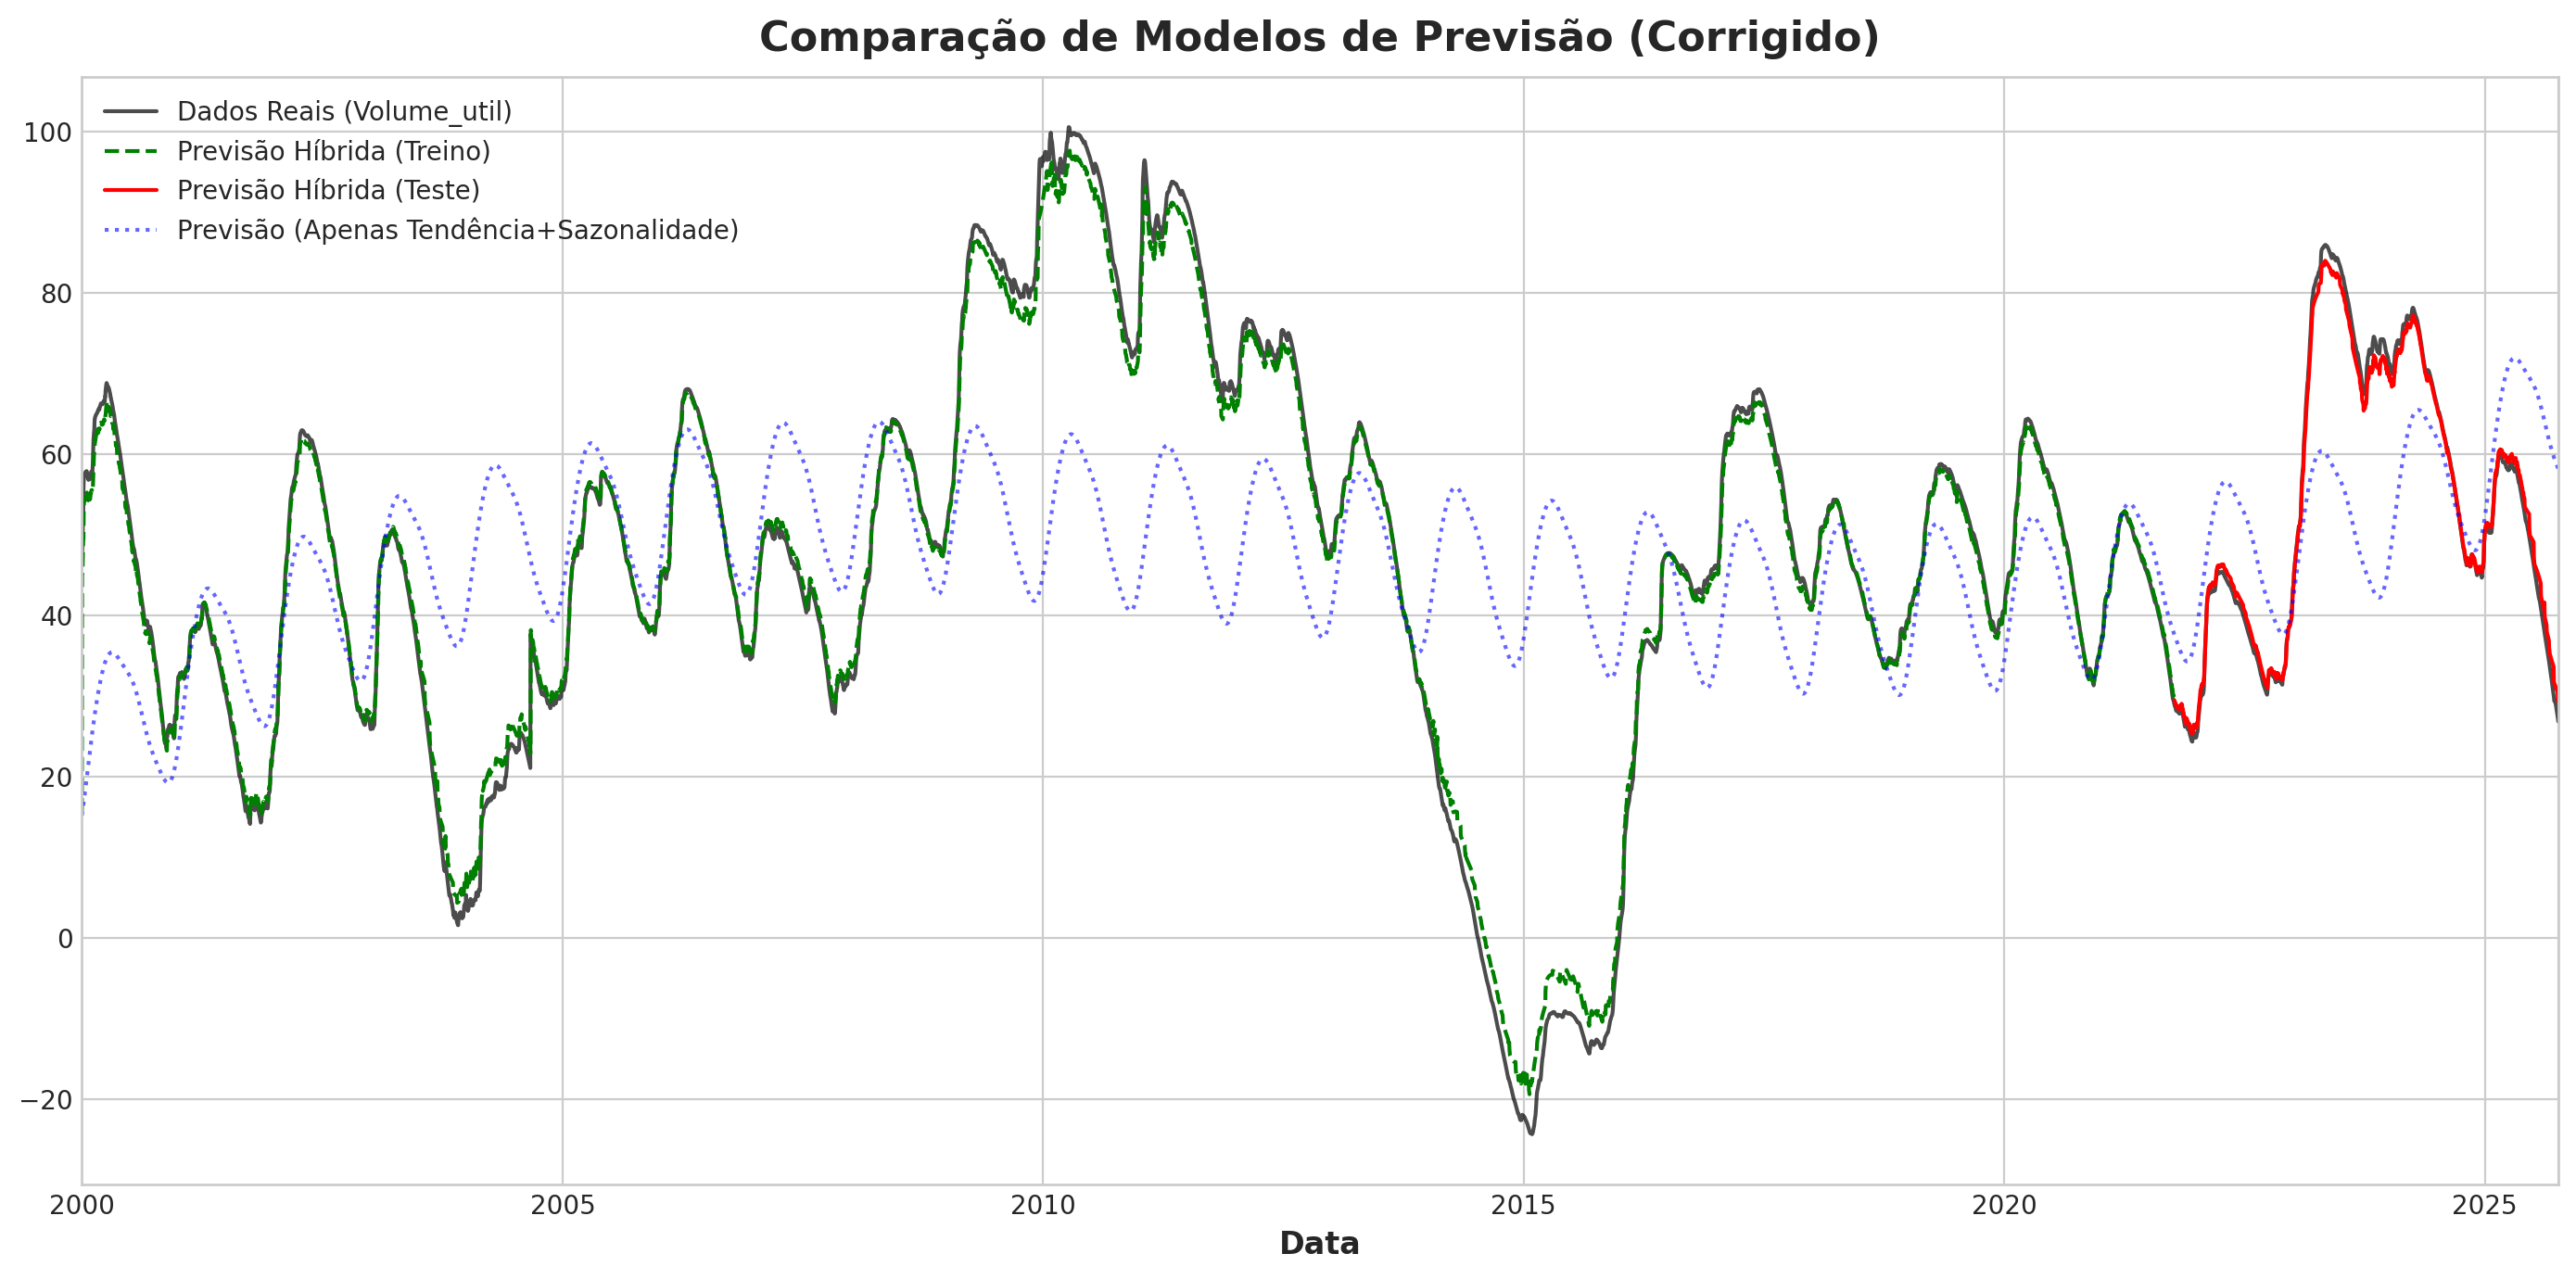

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

# Dados Reais
y1.plot(ax=ax, color='black', alpha=0.7, style='-', label='Dados Reais (Volume_util)')

# Previsão Híbrida Final
y_pred_final.plot(ax=ax, color='green', linestyle='--', label='Previsão Híbrida (Treino)')
y_fore_final.plot(ax=ax, color='red', linestyle='-', label='Previsão Híbrida (Teste)')

# Previsão do Modelo 1 para referência
y_pred1.plot(ax=ax, color='blue', alpha=0.6, linestyle=':', label='Previsão (Apenas Tendência+Sazonalidade)')

ax.set_title('Comparação de Modelos de Previsão')
ax.legend()
plt.show()

### Prevendo usando médias semanais

In [145]:
# --- FASE 1: Preparação e Divisão dos Dados ---

# Certifique-se de que o df_semanal está pronto
df_semanal = dfv[['Volume_util']].resample('W').mean()

# Criando o conjunto de TREINO (dados até o final de 2020)
df_treino = df_semanal.loc[:'2020-12-31']

# Criando o conjunto de TESTE (dados que temos de 2021 em diante, para validação)
df_teste = df_semanal.loc['2021-01-01':]

print(f"Último dado de treino: {df_treino.index.max().date()}")
print(f"Primeiro dado de teste: {df_teste.index.min().date()}")

Último dado de treino: 2020-12-27
Primeiro dado de teste: 2021-01-03


In [148]:
df_treino.head()

,Volume_util
Data,
2000-01-02,47.443865
2000-01-09,53.163856
2000-01-16,57.547054
2000-01-23,57.590323
2000-01-30,56.963061


In [ ]:
# --- FASE 2: Treinar os Modelos Apenas no Período de Treino ---


dp_treino = DeterministicProcess(
    index=df_treino.index,
    order=2,
    fourier=4,
    drop=True
)
x1_treino = dp_treino.in_sample()
y_treino = df_treino['Volume_util']

model1_treino = LinearRegression()
model1_treino.fit(x1_treino, y_treino)
y_pred1_treino = pd.Series(model1_treino.predict(x1_treino), index=y_treino.index)


y_res_treino = y_treino - y_pred1_treino


n_lags = 8
x2_treino = make_lags(y_res_treino, lags=n_lags)
x2_treino = x2_treino.fillna(0.0)

y_res_treino_aligned = y_res_treino.loc[x2_treino.index]

model2_treino = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=10)
model2_treino.fit(x2_treino, y_res_treino_aligned)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


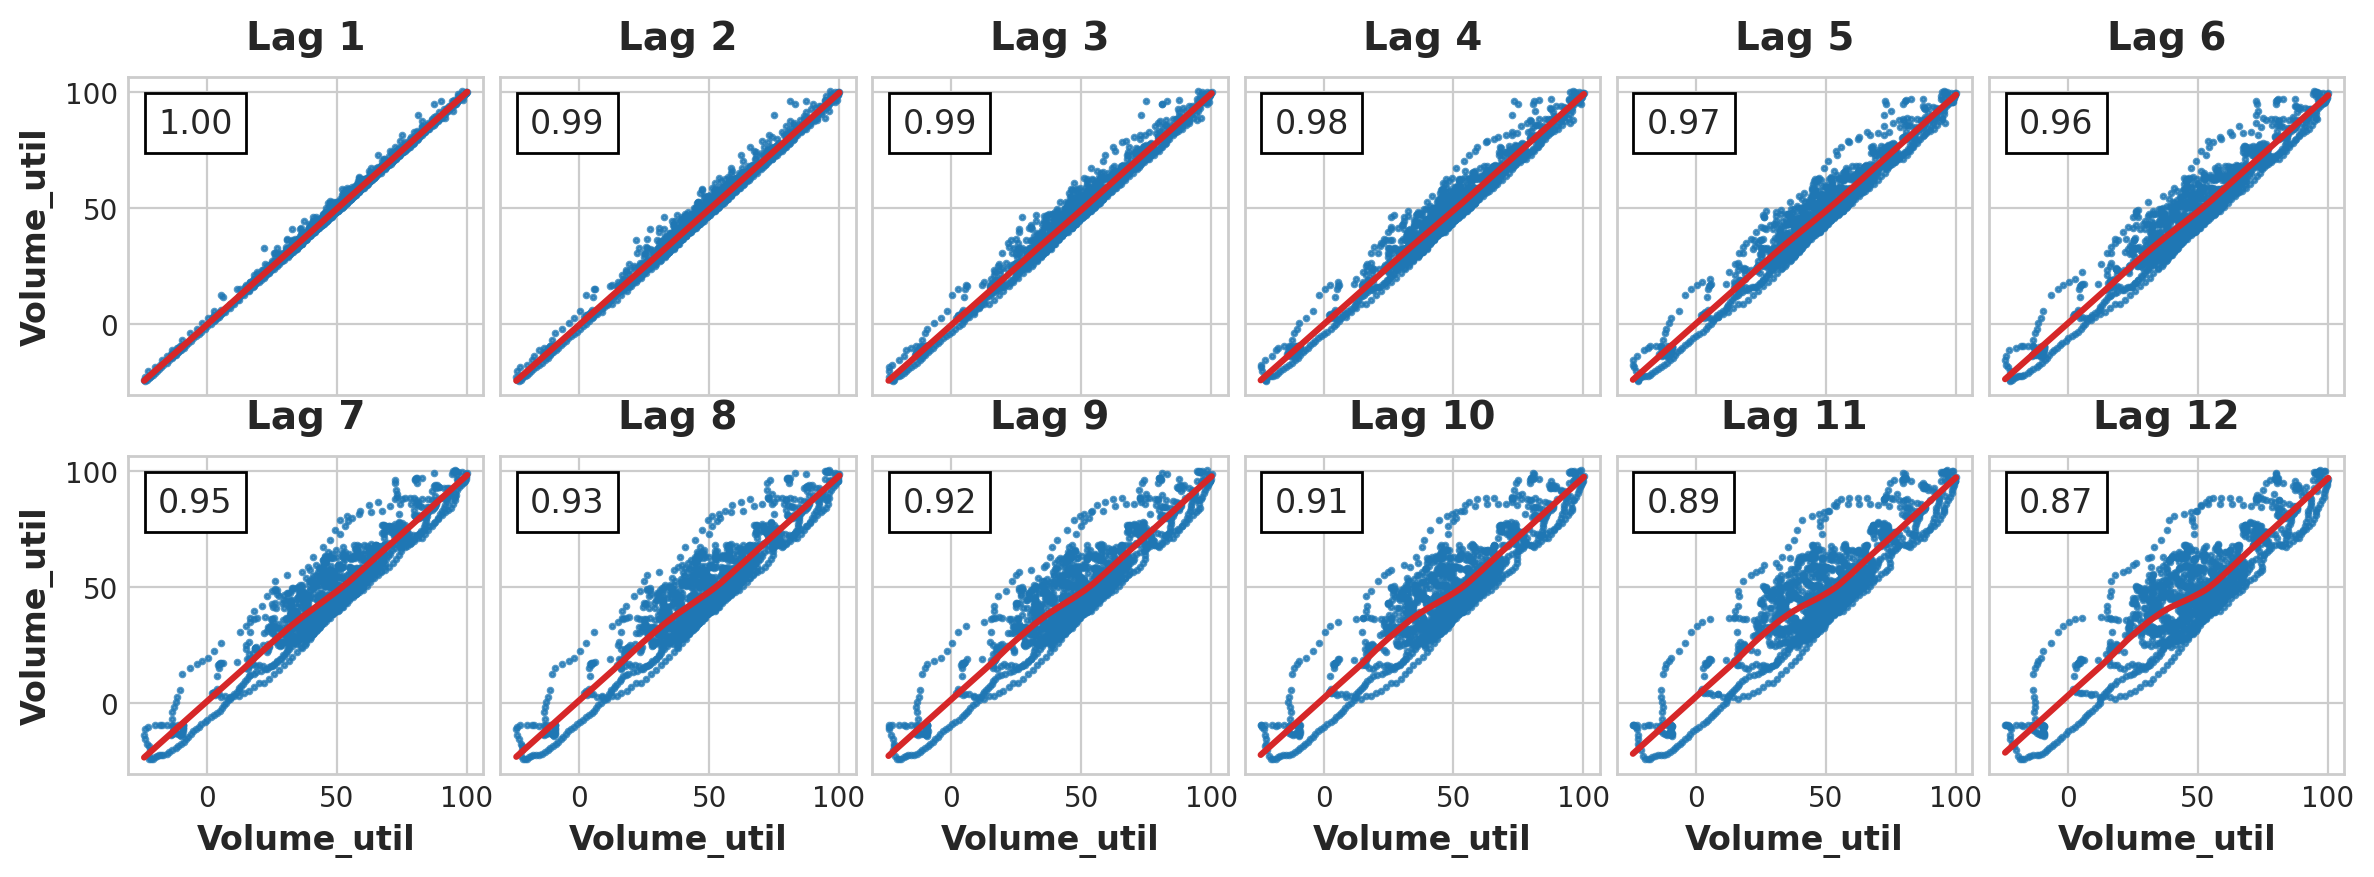

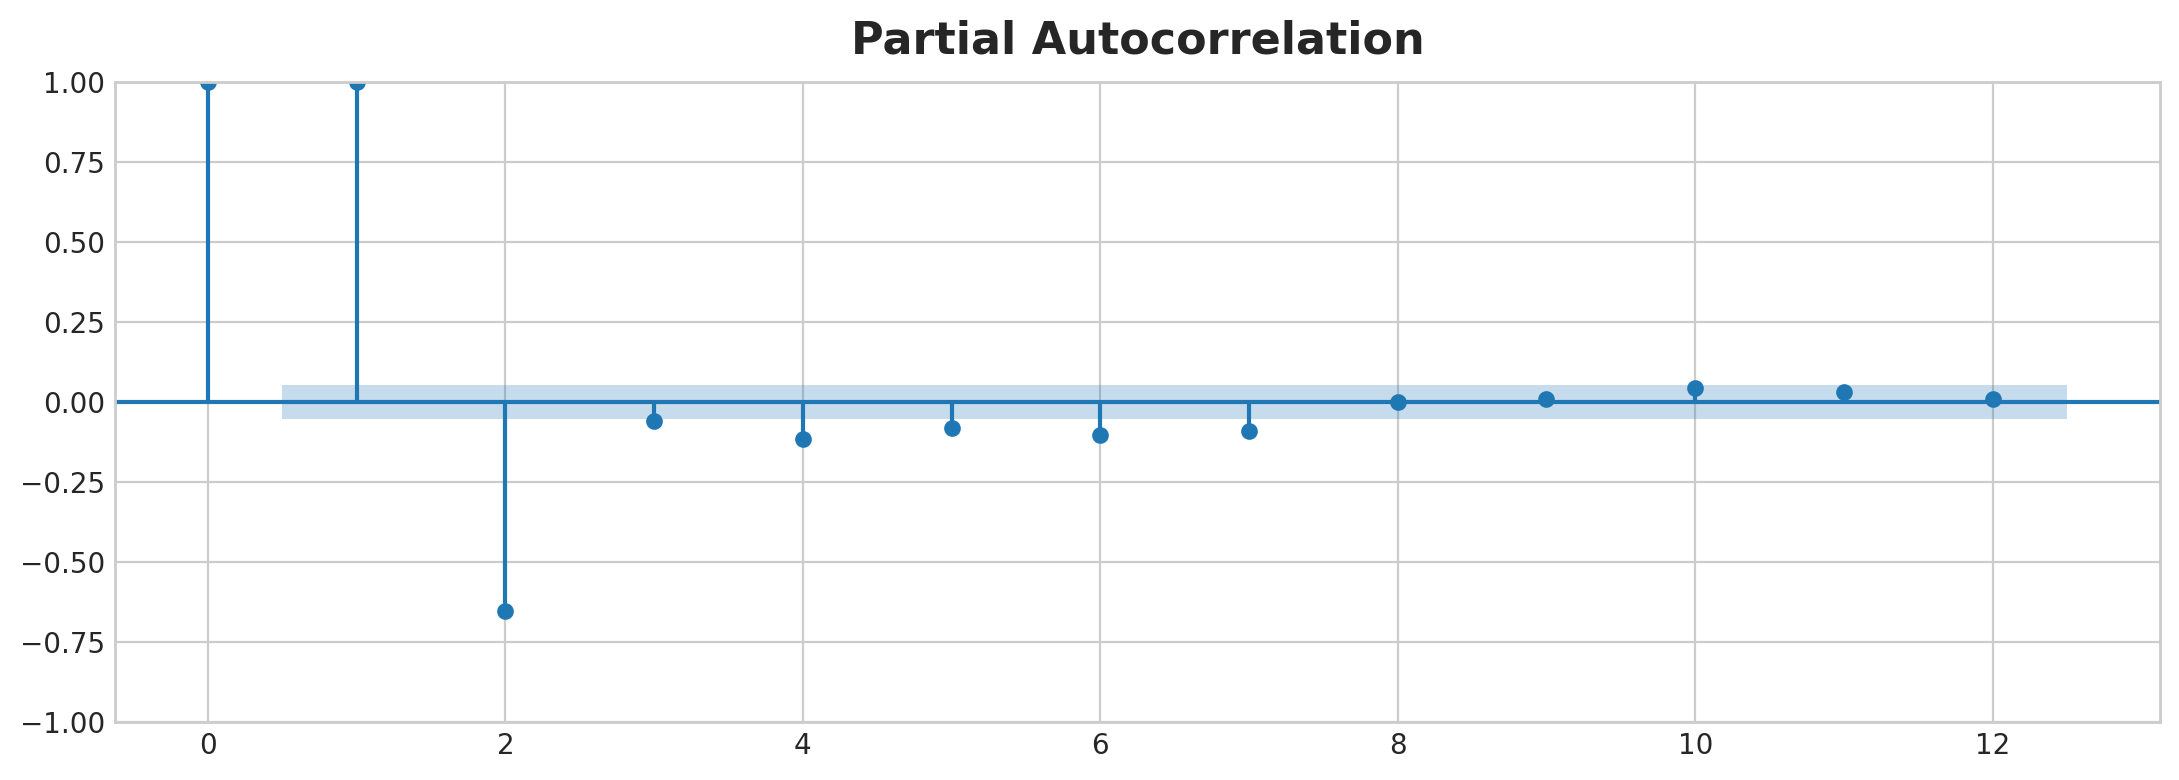

In [197]:
_ = plot_lags(df_semanal.Volume_util, lags=12, nrows=2)
_ = plot_pacf(df_semanal.Volume_util, lags=12)

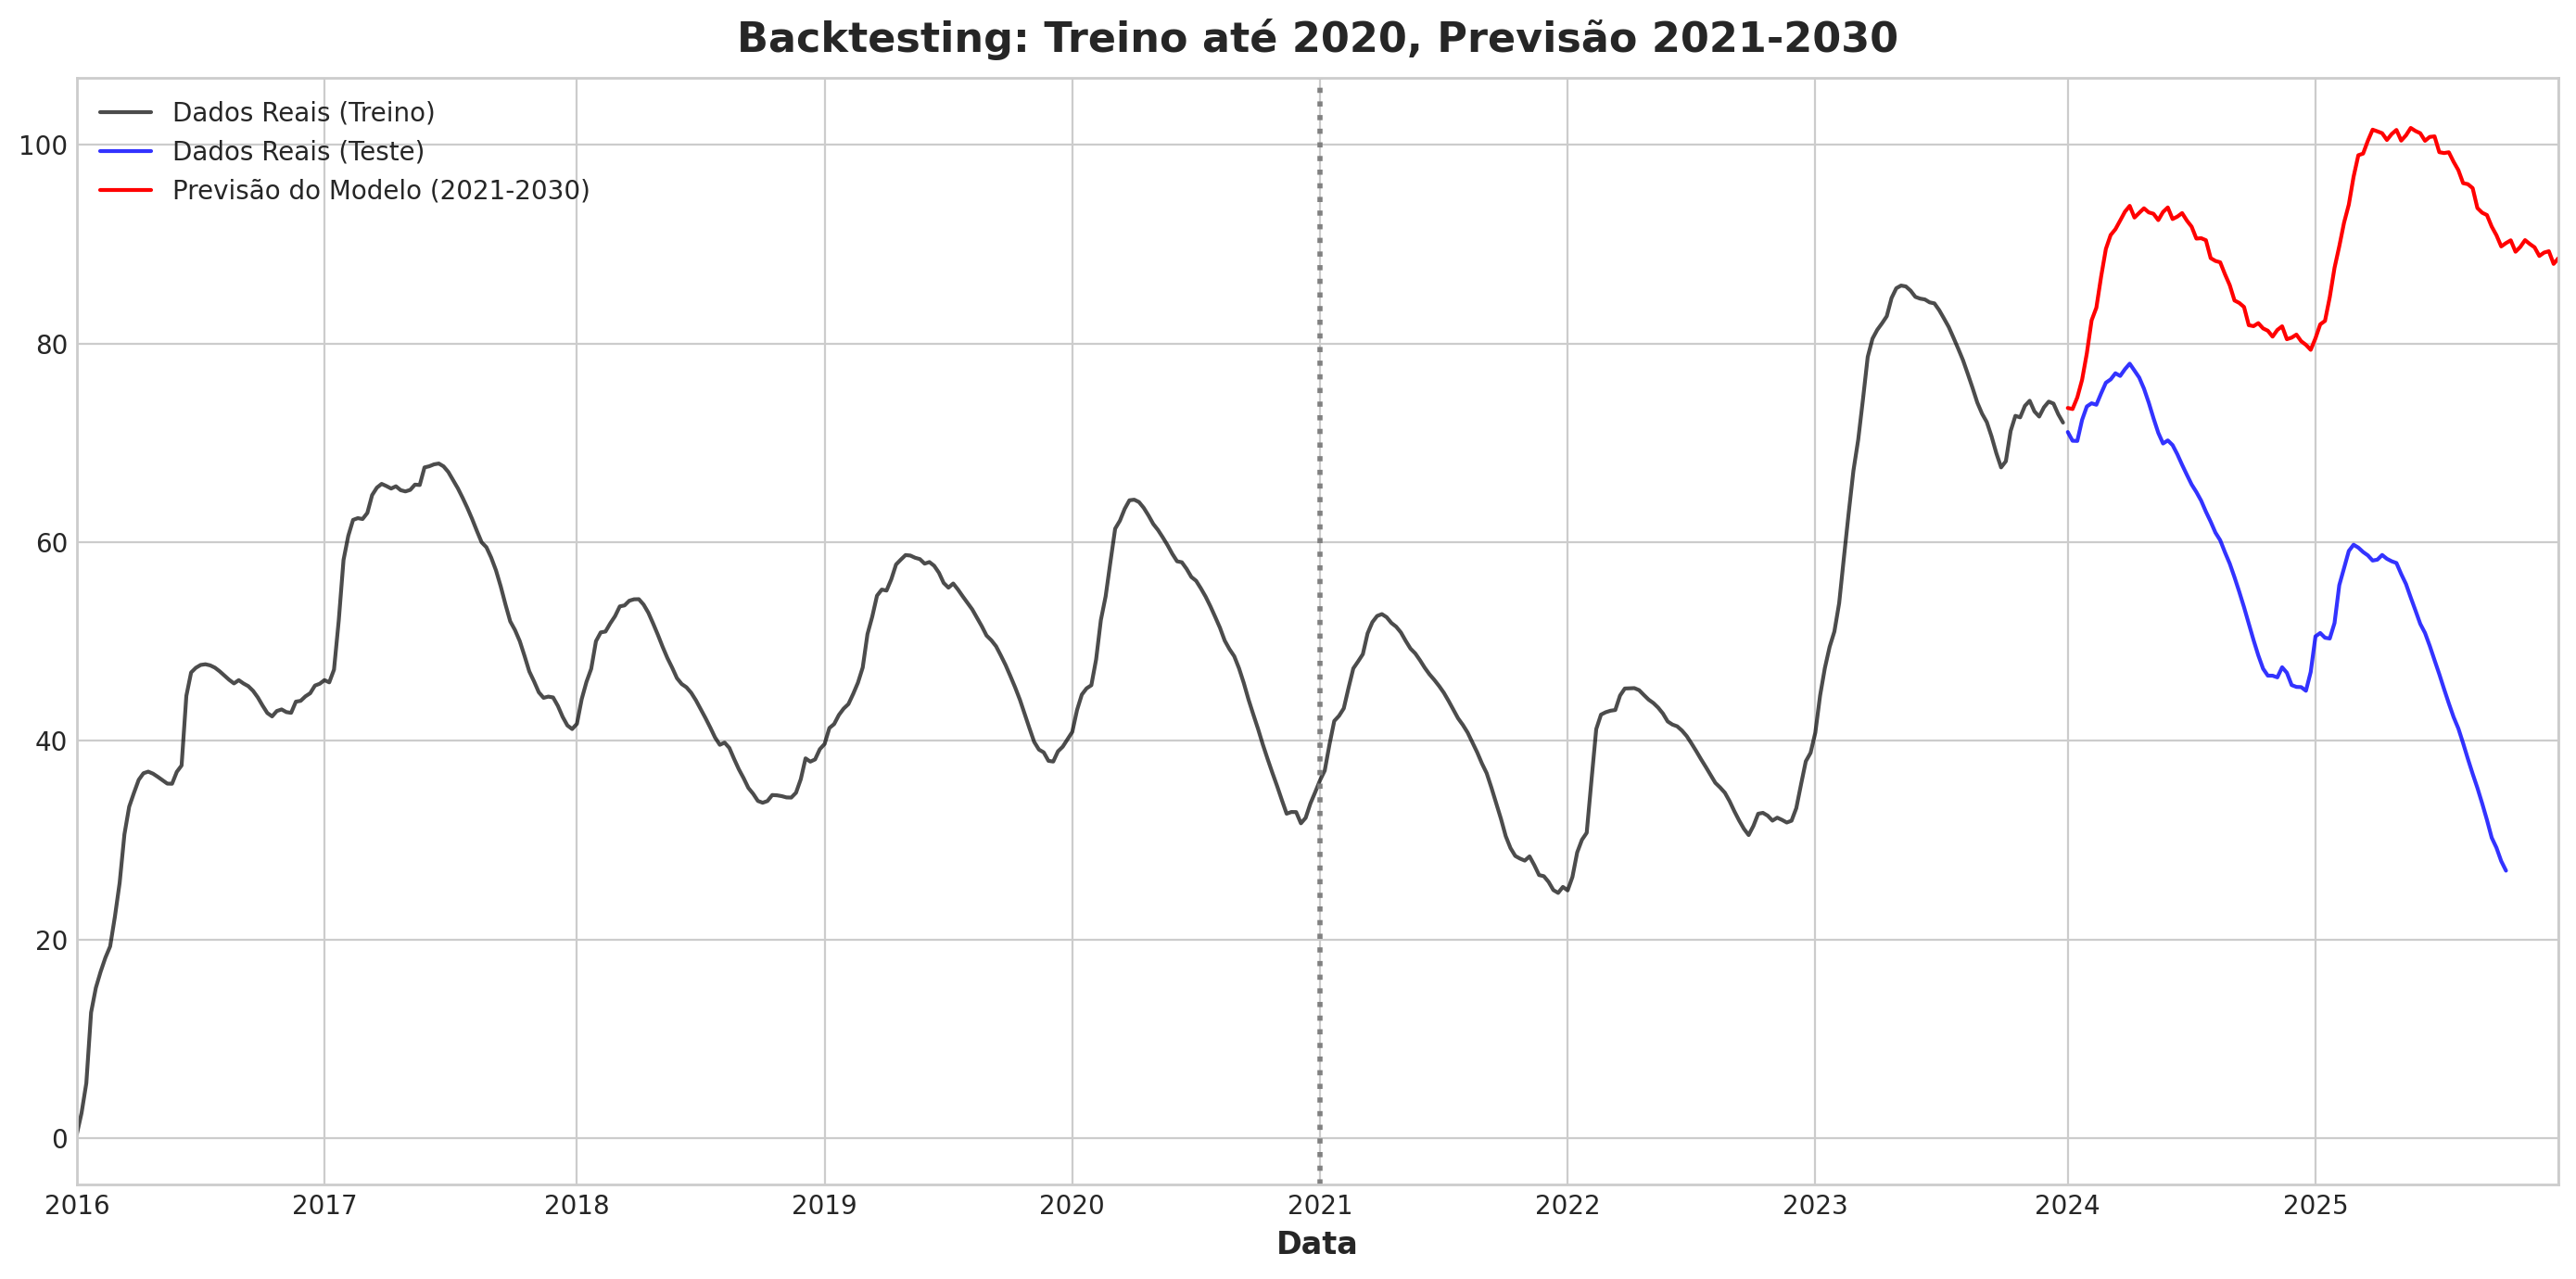

In [ ]:
# --- FASE 3: Previsão de Longo Prazo (2021-2030) ---


data_inicio_previsao = df_treino.index.max()
data_fim_previsao = pd.to_datetime('2025-12-31')
semanas_para_prever = len(pd.date_range(start=data_inicio_previsao, end=data_fim_previsao, freq='W')) -1


y_res_historico = y_res_treino_aligned.copy()


X_fore_deterministic = dp_treino.out_of_sample(steps=semanas_para_prever)

previsoes_finais = []

for i in range(semanas_para_prever):

    ultimos_lags = y_res_historico.tail(n_lags)
    X_fore_lags = pd.DataFrame([ultimos_lags.values], columns=x2_treino.columns, index=[X_fore_deterministic.index[i]])
    previsao_residuo = model2_treino.predict(X_fore_lags)[0]

    proxima_data = y_res_historico.index.max() + pd.Timedelta(weeks=1)
    y_res_historico.loc[proxima_data] = previsao_residuo

    previsao_1= model1_treino.predict(X_fore_deterministic.iloc[[i]])[0]
    previsao_final_semana = previsao_1 + previsao_residuo
    previsoes_finais.append(previsao_final_semana)

y_fore_total = pd.Series(previsoes_finais, index=X_fore_deterministic.index)


# --- PLOTAGEM ---
fig, ax = plt.subplots(figsize=(14, 7))

# Dados usados para o treino
y_treino.plot(ax=ax, style='-', color='black', alpha=0.7, label='Dados Reais (Treino)')

# Dados reais do período de teste (a "resposta correta")
df_teste['Volume_util'].plot(ax=ax, style='-', color='blue', alpha=0.8, label='Dados Reais (Teste)')

# Previsão completa do modelo
y_fore_total.plot(ax=ax, style='-', color='red', label='Previsão do Modelo (2021-2030)')

# Linha vertical para marcar a divisão
ax.axvline(pd.to_datetime('2020-12-31'), color='gray', linestyle=':', linewidth=2)

ax.set_title('Backtesting: Treino até 2020, Previsão 2021-2030')
ax.legend()
plt.show()

### Considerando apenas o periodo entre 2016 e 2025

In [224]:



df_semanal = dfv[['Volume_util']].resample('W').mean()


df_treino = df_semanal.loc['2016-01-01':'2023-12-31']


df_teste = df_semanal.loc['2024-01-01':]

print(f"Último dado de treino: {df_treino.index.max().date()}")
print(f"Primeiro dado de teste: {df_teste.index.min().date()}")

Último dado de treino: 2023-12-31
Primeiro dado de teste: 2024-01-07


In [225]:

dp_treino = DeterministicProcess(
    index=df_treino.index,
    order=2,
    fourier=4,
    drop=True
)
x1_treino = dp_treino.in_sample()
y_treino = df_treino['Volume_util']

model1_treino = LinearRegression()
model1_treino.fit(x1_treino, y_treino)
y_pred1_treino = pd.Series(model1_treino.predict(x1_treino), index=y_treino.index)


y_res_treino = y_treino - y_pred1_treino


n_lags = 8
x2_treino = make_lags(y_res_treino, lags=n_lags)
x2_treino = x2_treino.fillna(0.0)

y_res_treino_aligned = y_res_treino.loc[x2_treino.index]

model2_treino = XGBRegressor(n_estimators=50, learning_rate=0.05, max_depth=5)
model2_treino.fit(x2_treino, y_res_treino_aligned)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


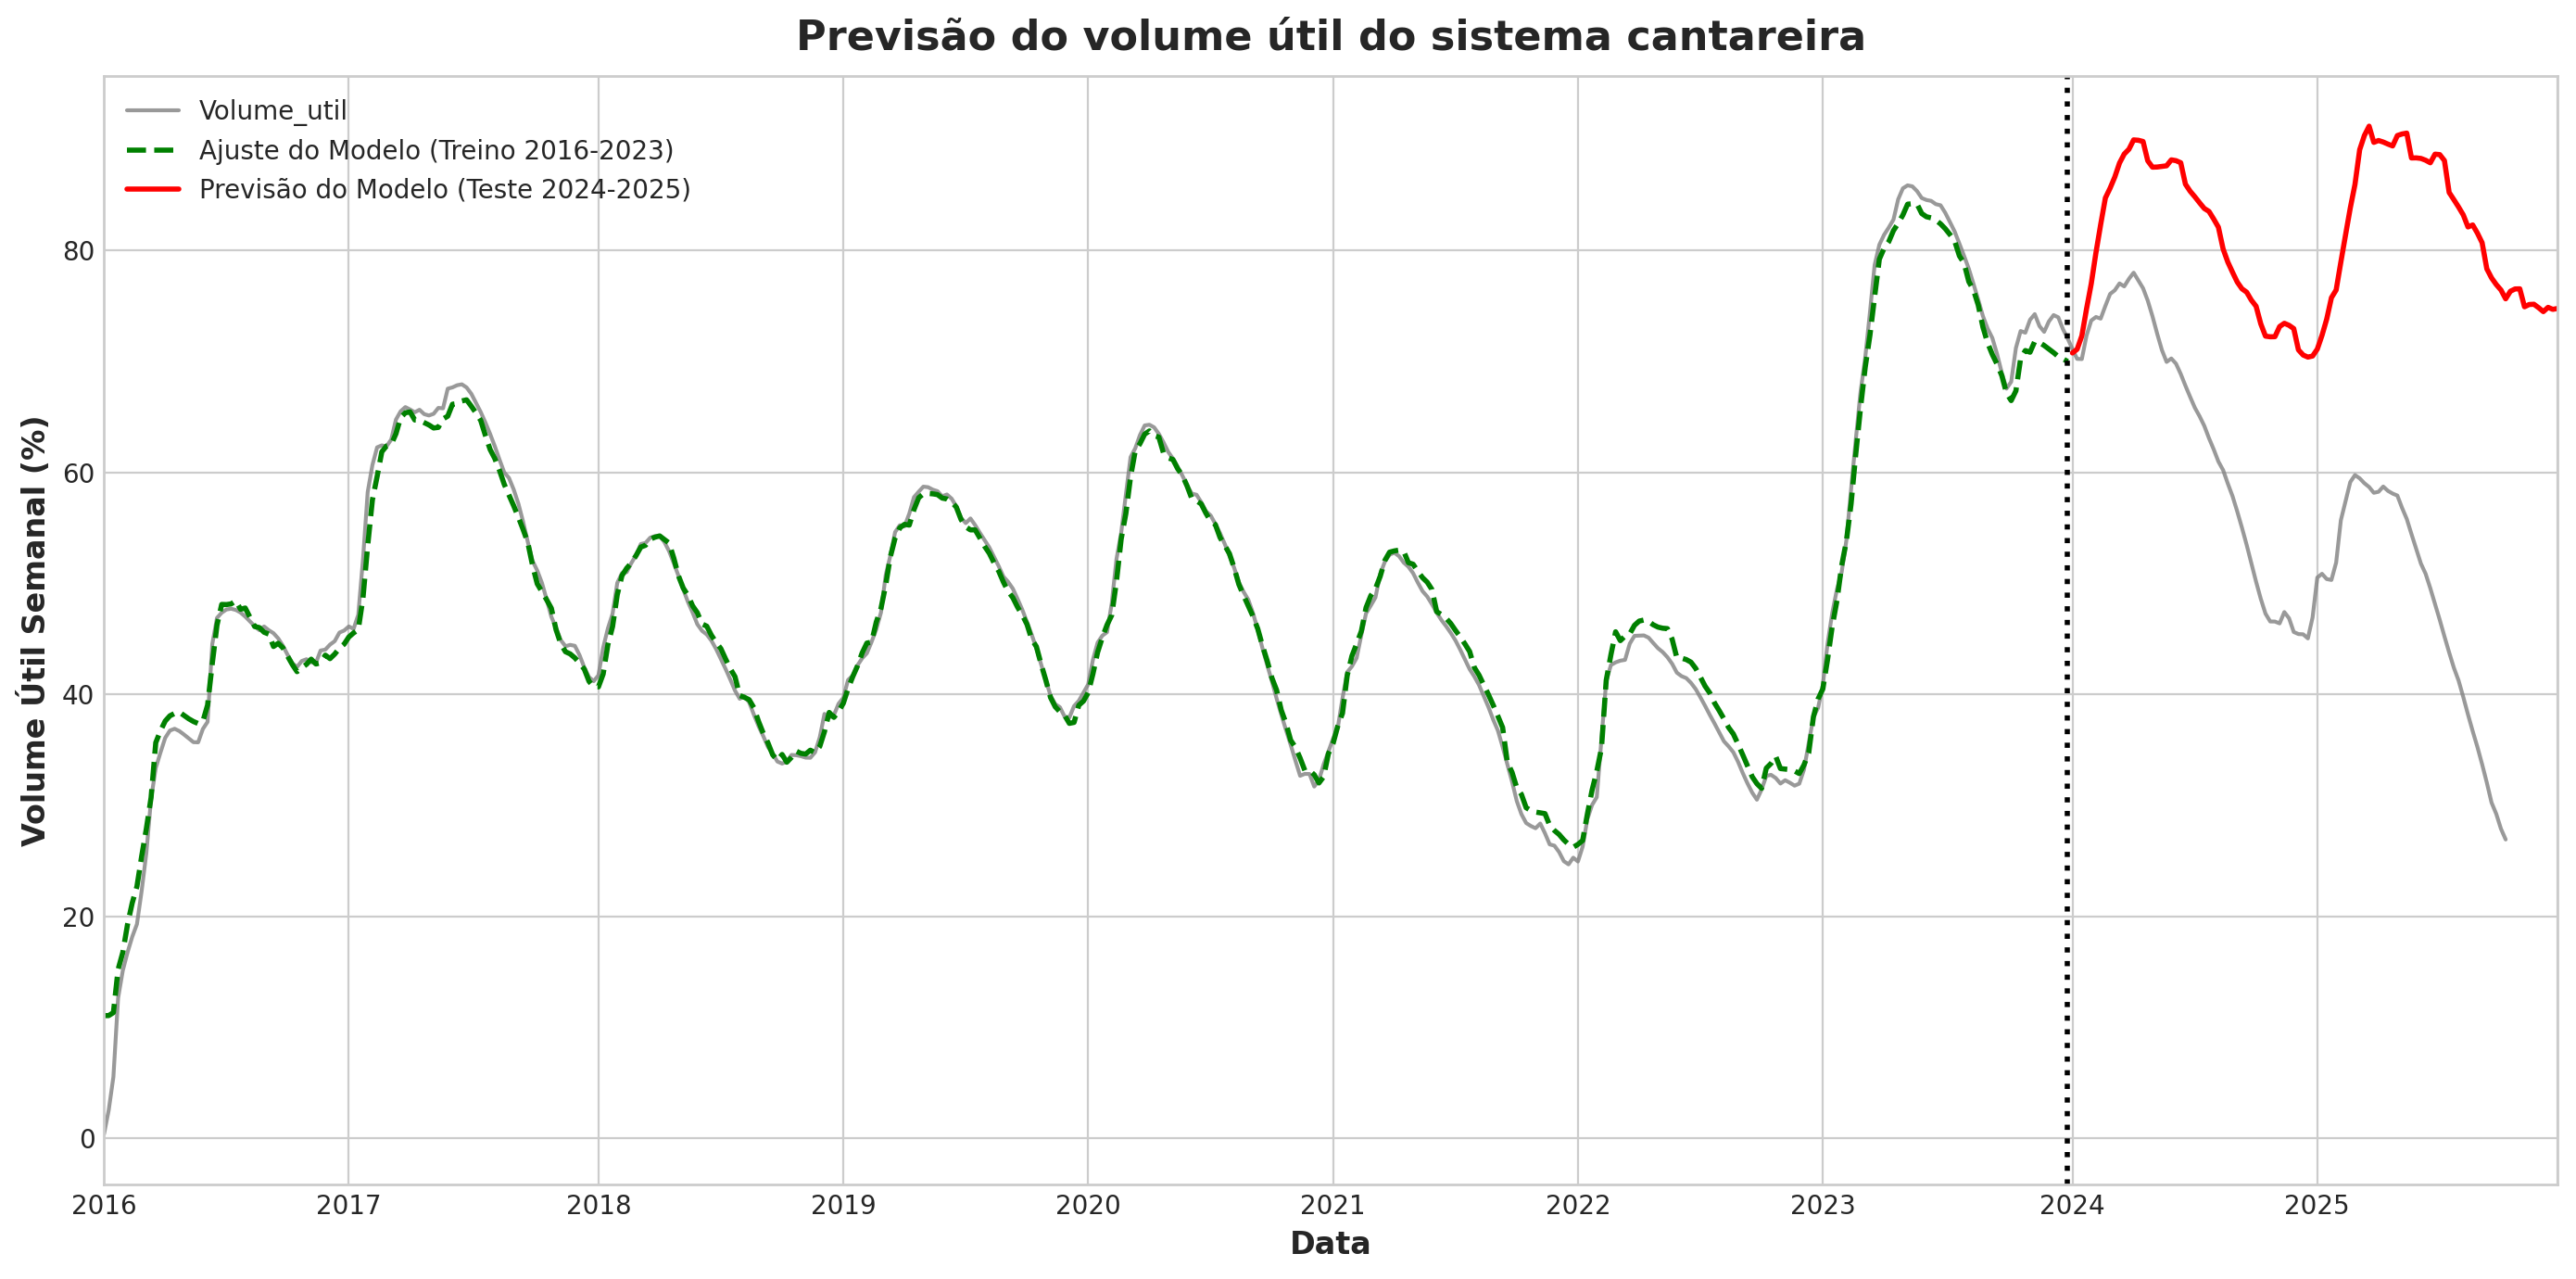

In [ ]:

y_pred_res_treino = pd.Series(model2_treino.predict(x2_treino), index=y_res_treino_aligned.index)
y_pred_treino_final = y_pred1_treino.loc[y_pred_res_treino.index] + y_pred_res_treino

data_inicio_previsao = df_treino.index.max()
data_fim_previsao = pd.to_datetime('2025-12-31')
semanas_para_prever = len(pd.date_range(start=data_inicio_previsao, end=data_fim_previsao, freq='W')) -1


y_res_historico = y_res_treino_aligned.copy()
X_fore_deterministic = dp_treino.out_of_sample(steps=semanas_para_prever)
previsoes_finais = []

for i in range(semanas_para_prever):
    ultimos_lags = y_res_historico.tail(n_lags)
    X_fore_lags = pd.DataFrame([ultimos_lags.values], columns=x2_treino.columns, index=[X_fore_deterministic.index[i]])
    previsao_residuo = model2_treino.predict(X_fore_lags)[0]
    proxima_data = y_res_historico.index.max() + pd.Timedelta(weeks=1)
    y_res_historico.loc[proxima_data] = previsao_residuo
    previsao_1 = model1_treino.predict(X_fore_deterministic.iloc[[i]])[0]
    previsao_final_semana = previsao_1 + previsao_residuo
    previsoes_finais.append(previsao_final_semana)

y_fore_2024_2025 = pd.Series(previsoes_finais, index=X_fore_deterministic.index)



fig, ax = plt.subplots(figsize=(14, 7))


df_semanal.loc['2016':].plot(
    ax=ax,
    style='-',
    color='gray',
    alpha=0.8,
    label='Dados Reais (2016-2025)'
)


y_pred_treino_final.plot(
    ax=ax,
    style='--',
    color='green',
    linewidth=2,
    label='Ajuste do Modelo (Treino 2016-2023)'
)


y_fore_2024_2025.plot(
    ax=ax,
    style='-',
    color='red',
    linewidth=2,
    label='Previsão do Modelo (Teste 2024-2025)'
)


ax.axvline(pd.to_datetime('2023-12-31'), color='black', linestyle=':', linewidth=2)


ax.set_title('Previsão do volume útil do sistema cantareira')
ax.set_xlabel('Data')
ax.set_ylabel('Volume Útil Semanal (%)')
ax.legend()
plt.show()

### Adicionando a chuva como uma variável exógena

In [227]:
df.head()

,Data,Chuva (mm),Volume Útil Armazenado (%),Volume Útil Armazenado (hm³),Volume Total Armazenado (hm³),Vazão Captada (m³/s),Vazão Produzida (m³/s),Vazão Jusante (m³/s),Vazão Natural (m³/s),Vazão Afluente (m³/s),Variação do Volume Útil (%),Chuva Acumulada no Mês (mm),Chuva Média Historica (mm),Vazão Jusante no mês (m³/s),Vazão Jusante Média Histórica (m³/s),Vazão Natural no Mês (m³/s),Vazão Natural Media Historica (m³/s),Vazão Produzida no Mês (m³/s),Vazão Retirada no Mês (m³/s)
0,2000-01-01,"30,9","47,11254","365,50555","1072,05098","29,0",NaN,"10,16","70,885","70,885","0,32635","30,9","261,51618","10,16","22,55533","70,885",NaN,NaN,"29,0"
1,2000-01-02,"29,1","47,77519","370,64646","1077,1919","28,8",NaN,"10,18","94,864","94,864","0,66265","60,0","261,51618","10,17","22,55533","82,875",NaN,NaN,"28,9"
2,2000-01-03,"35,175","48,59438","377,00187","1083,5473","33,3",NaN,"7,29","108,208","108,208","0,81919","95,175","261,51618","9,21","22,55533","91,319",NaN,NaN,"30,36667"
3,2000-01-04,"18,725","49,9968","387,88206","1094,42749","32,4",NaN,"6,34","162,936","162,936","1,40242","113,9","261,51618","8,4925","22,55533","109,223",NaN,NaN,"30,875"
4,2000-01-05,"25,9","51,94578","403,00251","1109,54794","32,9",NaN,"6,33","211,604","211,604","1,94898","139,8","261,51618","8,06","22,55533","129,699",NaN,NaN,"31,28"


In [228]:
df_chuva = df[['Data', 'Chuva (mm)']].copy()
df_chuva = df_chuva.rename(columns= {'Chuva (mm)':'chuva'})
df_chuva['Data'] = pd.to_datetime(df_chuva['Data'])
df_chuva = df_chuva.set_index('Data')
df_chuva.head()

,chuva
Data,
2000-01-01,"30,9"
2000-01-02,"29,1"
2000-01-03,"35,175"
2000-01-04,"18,725"
2000-01-05,"25,9"


In [229]:
df_chuva['chuva'] = df_chuva['chuva'].str.strip()
df_chuva['chuva'] = df_chuva['chuva'].str.replace(',','.', regex=False)
df_chuva['chuva'] = pd.to_numeric(df_chuva['chuva'])

In [230]:
df_chuva.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9412 entries, 2000-01-01 to 2025-10-07
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   chuva   9412 non-null   float64
dtypes: float64(1)
memory usage: 147.1 KB


In [241]:
df_chuva_semanal = df_chuva[['chuva']].resample('W').sum()

df_semanal_completo = df_semanal.join(df_chuva_semanal)

print("--- DataFrame Completo (Volume + Chuva Semanal) ---")
print(df_semanal_completo.head())

--- DataFrame Completo (Volume + Chuva Semanal) ---
            Volume_util    chuva
Data                            
2000-01-02    47.443865   60.000
2000-01-09    53.163856  115.275
2000-01-16    57.547054   23.500
2000-01-23    57.590323   18.050
2000-01-30    56.963061   26.950


In [242]:
# Criando features de lag para a chuva
df_semanal_completo['chuva_lag_1'] = df_semanal_completo['chuva'].shift(1)
df_semanal_completo['chuva_lag_2'] = df_semanal_completo['chuva'].shift(2)
df_semanal_completo['chuva_lag_4'] = df_semanal_completo['chuva'].shift(4)

# Criando features de soma móvel (chuva acumulada)
# .rolling(4) cria uma janela de 4 semanas. .sum() calcula a soma.
# min_periods=1 garante que ele calcule mesmo se a janela não estiver cheia no começo.
df_semanal_completo['chuva_acumulada_4_semanas'] = df_semanal_completo['chuva'].shift(1).rolling(4, min_periods=1).sum()
df_semanal_completo['chuva_acumulada_12_semanas'] = df_semanal_completo['chuva'].shift(1).rolling(12, min_periods=1).sum()

# Remova os NaNs criados pelos lags e rolling
df_semanal_completo = df_semanal_completo.dropna()

print("\n--- DataFrame com Features de Chuva ---")
print(df_semanal_completo.head())


--- DataFrame com Features de Chuva ---
            Volume_util    chuva  chuva_lag_1  chuva_lag_2  chuva_lag_4  \
Data                                                                      
2000-01-30    56.963061   26.950       18.050       23.500       60.000   
2000-02-06    57.392224   57.500       26.950       18.050      115.275   
2000-02-13    58.428343  102.125       57.500       26.950       23.500   
2000-02-20    63.204300   53.500      102.125       57.500       18.050   
2000-02-27    64.849679   16.850       53.500      102.125       26.950   

            chuva_acumulada_4_semanas  chuva_acumulada_12_semanas  
Data                                                               
2000-01-30                    216.825                     216.825  
2000-02-06                    183.775                     243.775  
2000-02-13                    126.000                     301.275  
2000-02-20                    204.625                     403.400  
2000-02-27               

In [245]:
df_treino_ = df_semanal_completo.loc['2016-01-01':'2023-12-31']
df_teste_ = df_semanal_completo.loc['2024-01-01':]

# --- Treinamento dos Modelos ---

dp_treino = DeterministicProcess(index=df_treino_.index, order=2, fourier=4, drop=True)
x1_treino = dp_treino.in_sample()
y_treino = df_treino_['Volume_util']
model1_treino = LinearRegression()
model1_treino.fit(x1_treino, y_treino)
y_pred1_treino = pd.Series(model1_treino.predict(x1_treino), index=y_treino.index)

y_res_treino = y_treino - y_pred1_treino


features_de_chuva = ['chuva_lag_1', 'chuva_lag_2', 'chuva_lag_4', 'chuva_acumulada_4_semanas', 'chuva_acumulada_12_semanas']
lags_dos_residuos = make_lags(y_res_treino, lags=8)


x2_treino_completo = lags_dos_residuos.join(df_treino_[features_de_chuva])
x2_treino_completo = x2_treino_completo.fillna(0.0) 


y_res_treino_aligned = y_res_treino.loc[x2_treino_completo.index]


model2_treino = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5) 
model2_treino.fit(x2_treino_completo, y_res_treino_aligned)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [249]:
x1_treino.head()

,trend,trend_squared,"sin(1,52)","cos(1,52)","sin(2,52)","cos(2,52)","sin(3,52)","cos(3,52)","sin(4,52)","cos(4,52)"
Data,,,,,,,,,,
2016-01-03,1.0,1.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
2016-01-10,2.0,4.0,0.120537,0.992709,0.239316,0.970942,0.354605,0.935016,0.464723,0.885456
2016-01-17,3.0,9.0,0.239316,0.970942,0.464723,0.885456,0.663123,0.748511,0.822984,0.568065
2016-01-24,4.0,16.0,0.354605,0.935016,0.663123,0.748511,0.885456,0.464723,0.992709,0.120537
2016-01-31,5.0,25.0,0.464723,0.885456,0.822984,0.568065,0.992709,0.120537,0.935016,-0.354605


In [250]:
df_treino_.corr()

,Volume_util,chuva,chuva_lag_1,chuva_lag_2,chuva_lag_4,chuva_acumulada_4_semanas,chuva_acumulada_12_semanas
Volume_util,1.000000,-0.184439,-0.117275,-0.075124,-0.003781,-0.082332,0.120445
chuva,-0.184439,1.000000,0.368289,0.314542,0.233651,0.429143,0.343410
chuva_lag_1,-0.117275,0.368289,1.000000,0.371219,0.309045,0.699849,0.490831
chuva_lag_2,-0.075124,0.314542,0.371219,1.000000,0.318838,0.723641,0.532730
chuva_lag_4,-0.003781,0.233651,0.309045,0.318838,1.000000,0.703034,0.601145
chuva_acumulada_4_semanas,-0.082332,0.429143,0.699849,0.723641,0.703034,1.000000,0.768617
chuva_acumulada_12_semanas,0.120445,0.343410,0.490831,0.532730,0.601145,0.768617,1.000000


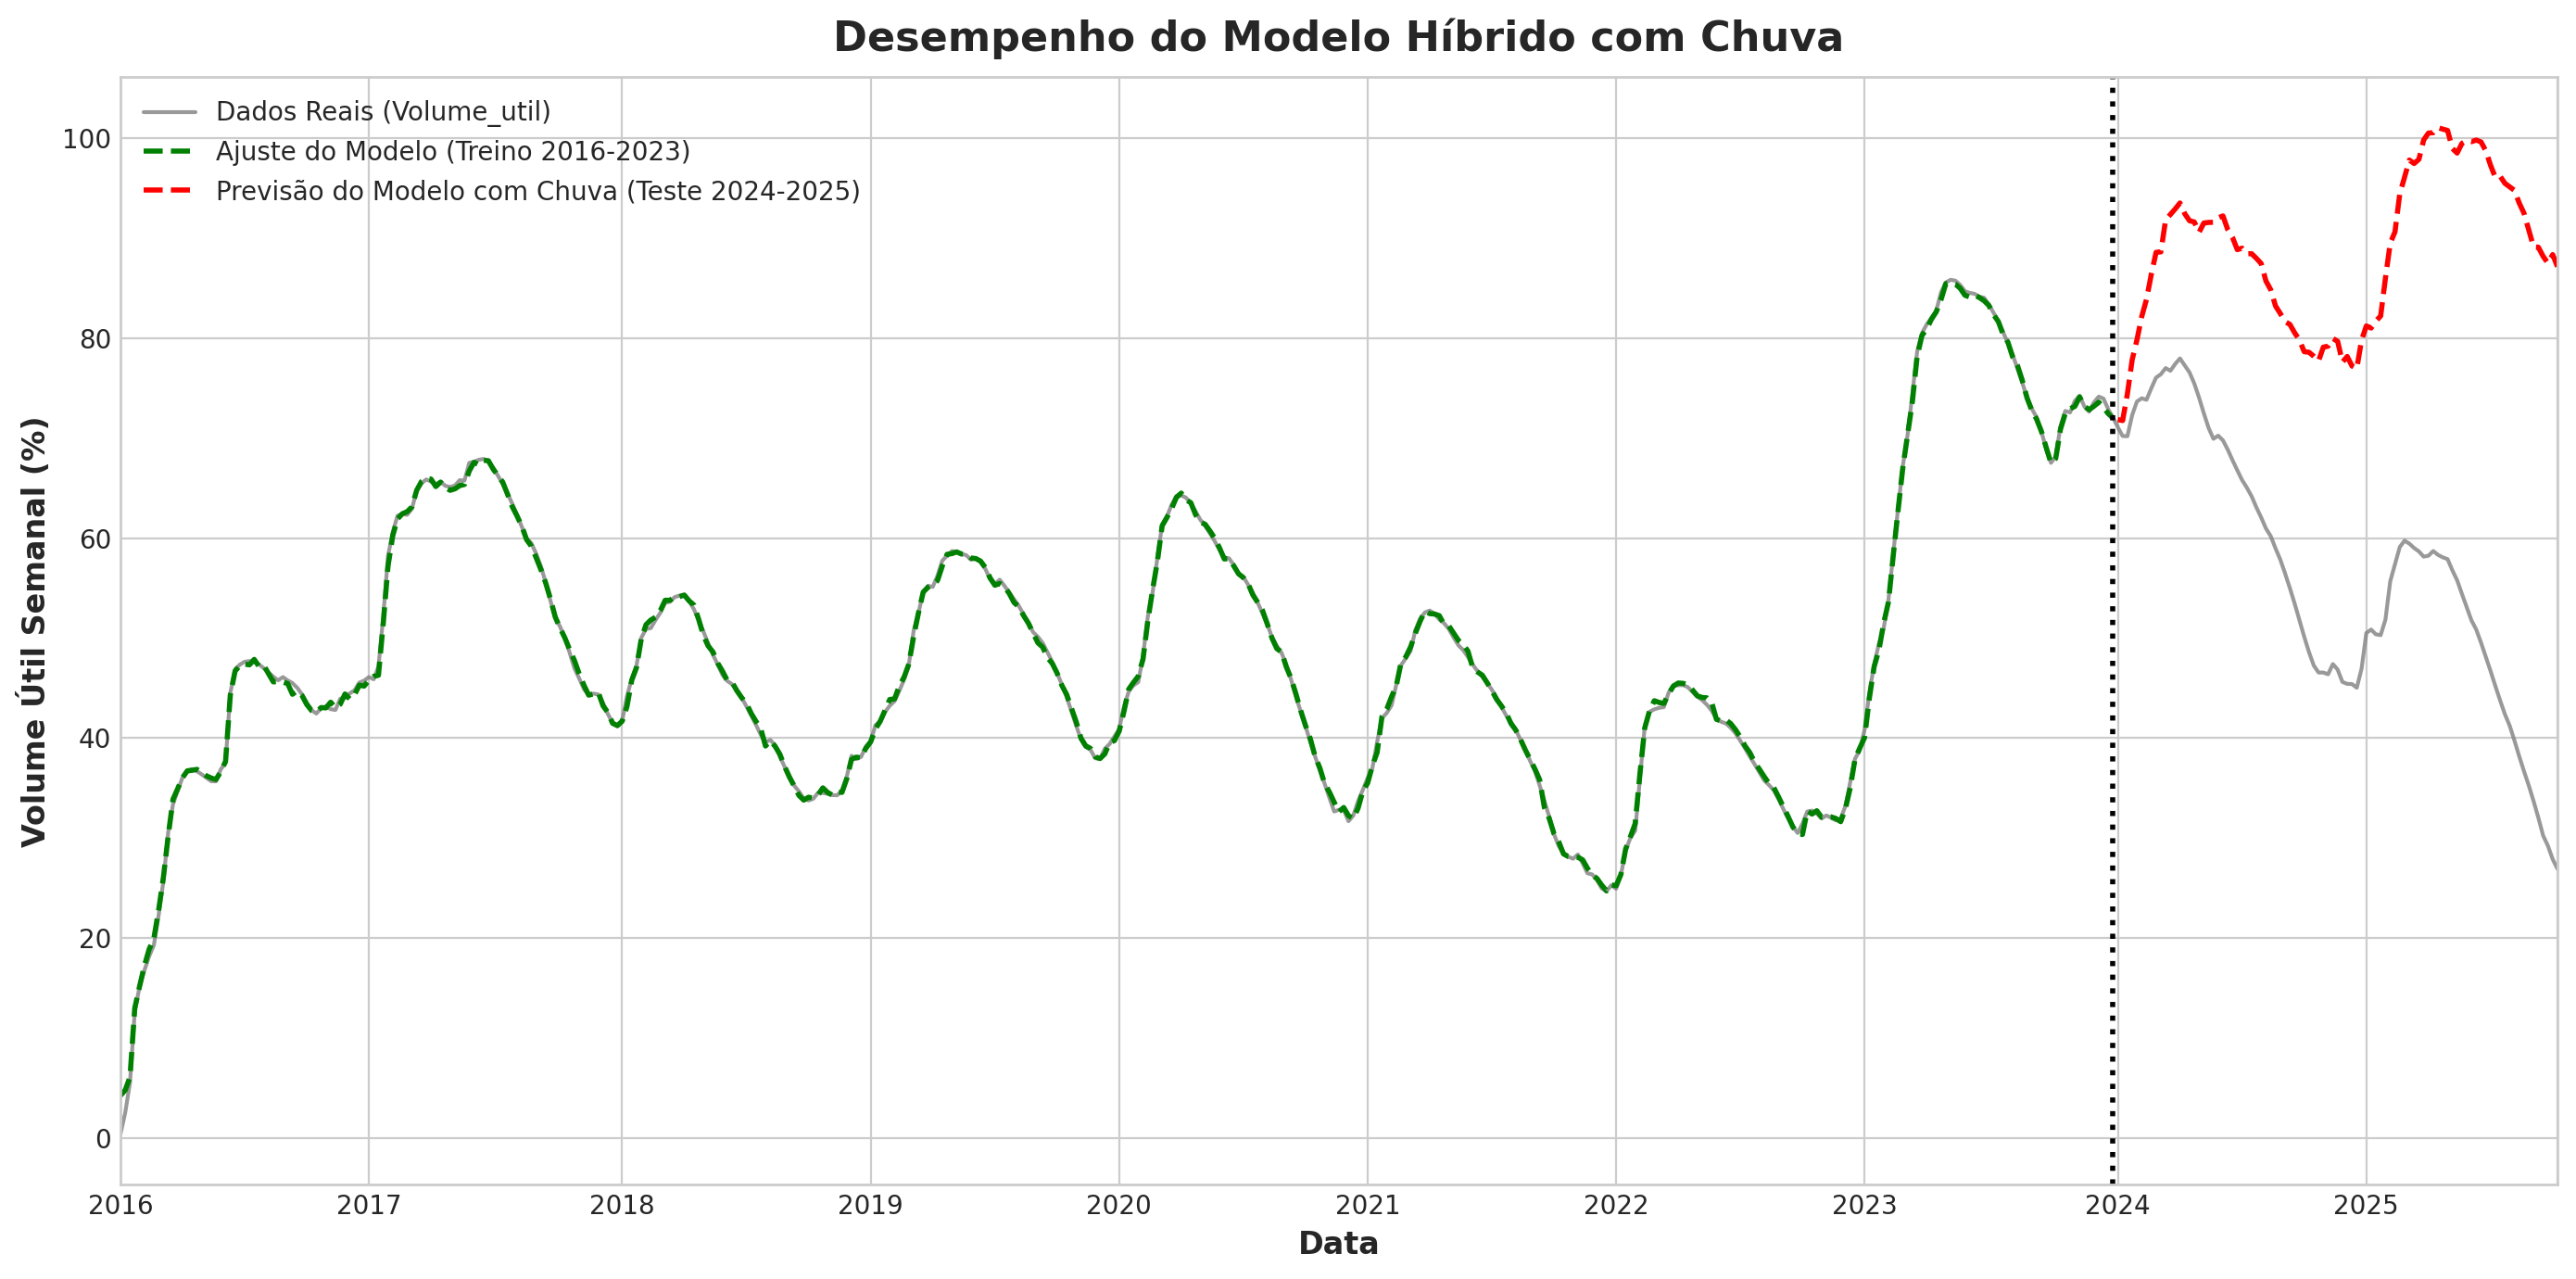

In [ ]:

y_pred_res_treino = pd.Series(model2_treino.predict(x2_treino_completo), index=y_res_treino_aligned.index)
y_pred_treino_final = y_pred1_treino.loc[y_pred_res_treino.index] + y_pred_res_treino



data_inicio_previsao = df_treino_.index.max()
data_fim_previsao = df_teste_.index.max() 
semanas_para_prever = len(pd.date_range(start=data_inicio_previsao, end=data_fim_previsao, freq='W')) -1


y_res_historico = y_res_treino_aligned.copy()


X_fore_deterministic = dp_treino.out_of_sample(steps=semanas_para_prever)

previsoes_finais = []

for i in range(semanas_para_prever):
    # 1. Pegue as features de lag dos resíduos (baseado no histórico que inclui previsões passadas)
    ultimos_lags = y_res_historico.tail(n_lags)
    X_fore_lags = pd.DataFrame([ultimos_lags.values], columns=lags_dos_residuos.columns, index=[X_fore_deterministic.index[i]])

    # 2. Pegue as features de CHUVA do período futuro (os dados reais de chuva)
    X_fore_chuva = df_teste_[features_de_chuva].iloc[[i]]

    # 3. Combine as features (lags + chuva) para o XGBoost
    # Garanta que a ordem das colunas seja a mesma do treino!
    X_fore_combinado = X_fore_lags.join(X_fore_chuva)
    X_fore_combinado = X_fore_combinado[x2_treino_completo.columns] # Garante a ordem correta

    # 4. Preveja o resíduo da próxima semana
    previsao_residuo = model2_treino.predict(X_fore_combinado)[0]

    # 5. Adicione essa previsão de resíduo ao histórico para o próximo loop
    proxima_data = y_res_historico.index.max() + pd.Timedelta(weeks=1)
    y_res_historico.loc[proxima_data] = previsao_residuo

    # 6. Calcule a previsão final: Previsão Estrategista + Previsão do Resíduo
    previsao_1= model1_treino.predict(X_fore_deterministic.iloc[[i]])[0]
    previsao_final_semana = previsao_1 + previsao_residuo
    previsoes_finais.append(previsao_final_semana)

# Transforme a lista de previsões em uma Série do Pandas
y_fore_com_chuva = pd.Series(previsoes_finais, index=X_fore_deterministic.index)


# --- FASE 4: PLOTAGEM FINAL ---
fig, ax = plt.subplots(figsize=(14, 7))

# 1. Dados Reais (ao fundo em cinza)
df_semanal_completo.loc['2016':]['Volume_util'].plot(
    ax=ax, style='-', color='gray', alpha=0.8, label='Dados Reais (Volume_util)'
)

# 2. Ajuste do Modelo no período de treino
y_pred_treino_final.plot(
    ax=ax, style='--', color='green', linewidth=2, label='Ajuste do Modelo (Treino 2016-2023)'
)

# 3. Previsão do Modelo com Chuva no período de teste
y_fore_com_chuva.plot(
    ax=ax, style='--', color='red', linewidth=2, label='Previsão do Modelo com Chuva (Teste 2024-2025)'
)

# 4. Linha vertical para marcar a divisão
ax.axvline(pd.to_datetime('2023-12-31'), color='black', linestyle=':', linewidth=2)

ax.set_title('Desempenho do Modelo Híbrido com Chuva')
ax.set_xlabel('Data')
ax.set_ylabel('Volume Útil Semanal (%)')
ax.legend()
plt.show()

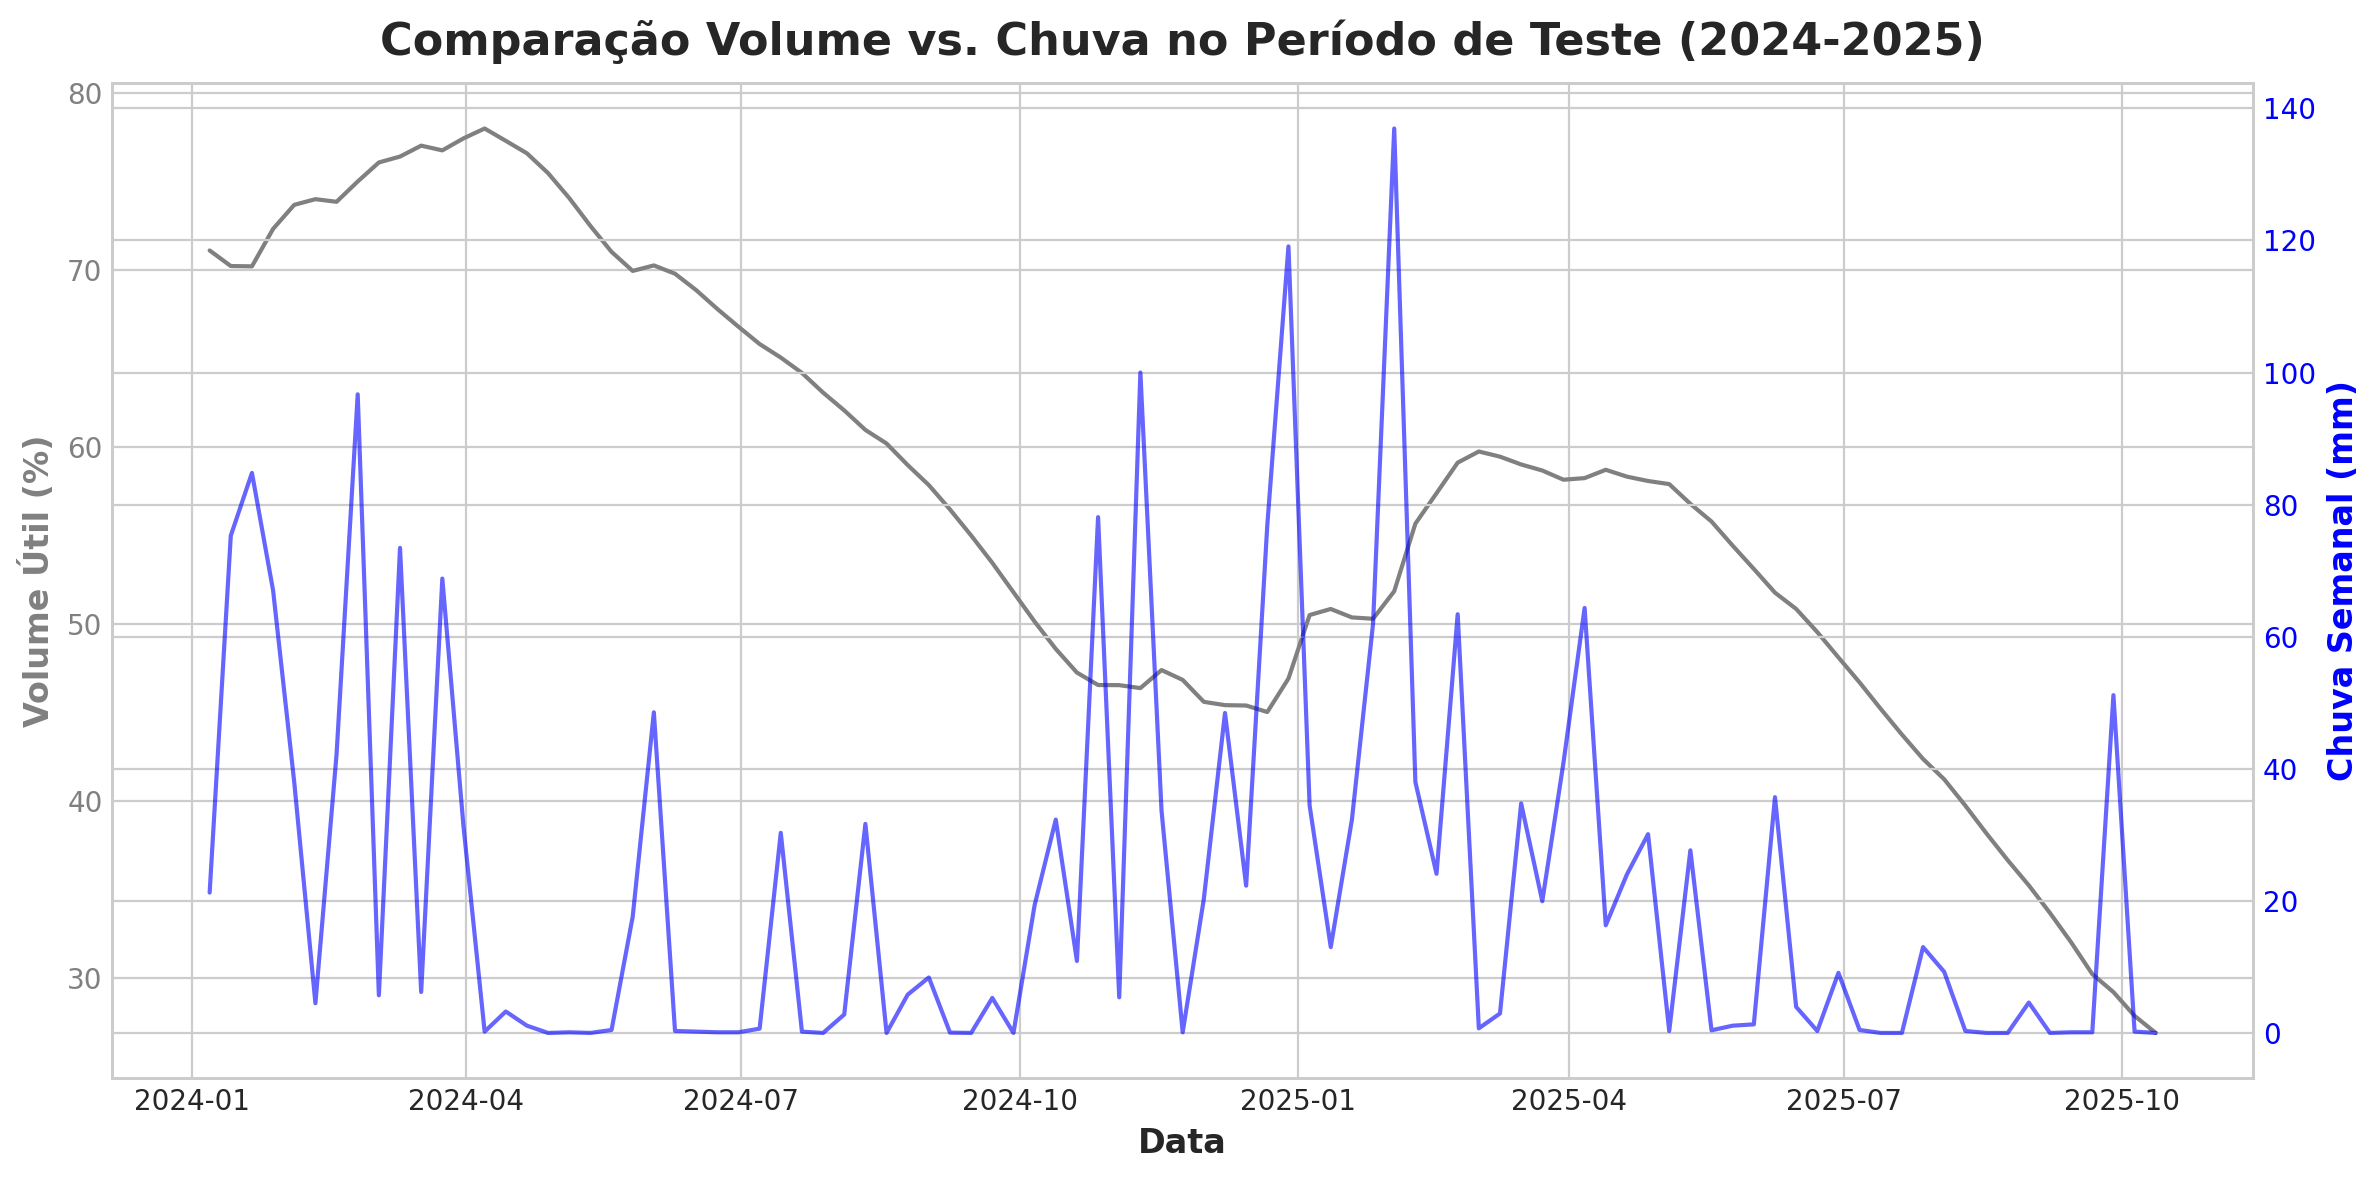

In [248]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eixo 1: Volume
ax1.plot(df_teste_.index, df_teste_['Volume_util'], color='gray', label='Volume Útil (%)')
ax1.set_xlabel('Data')
ax1.set_ylabel('Volume Útil (%)', color='gray')
ax1.tick_params(axis='y', labelcolor='gray')

# Eixo 2: Chuva (compartilhando o mesmo eixo X)
ax2 = ax1.twinx()
ax2.plot(df_teste_.index, df_teste_['chuva'], color='blue', alpha=0.6, label='Chuva Semanal (mm)')
ax2.set_ylabel('Chuva Semanal (mm)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Comparação Volume vs. Chuva no Período de Teste (2024-2025)')
plt.show()